<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.875 · Deep Learning · PEC3</p>
<p style="margin: 0; text-align:right;">2025-2 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PEC 3: Transformers con Pytorch


<u>Consideraciones generales</u>:

- Esta PEC debe realizarse de forma **estrictamente individual**. Cualquier indicio de copia será penalizado con un suspenso (D) para todas las partes implicadas y la posible evaluación negativa de la asignatura de forma íntegra.
- Es necesario que el estudiante indique **todas las fuentes** que ha utilizado para la realización de la PEC. De no ser así, se considerará que el estudiante ha cometido plagio, siendo penalizado con un suspenso (D) y la posible evaluación negativa de la asignatura de forma íntegra.
- Si se usa cualquier <strong>IA generativa</strong> en la resolución de la PEC <strong> se tiene que referenciar</strong> en aquellas secciones donde se haya usado, como cualquier otra fuente.

<u>Formato de la entrega</u>:

- Algunos ejercicios pueden suponer varios minutos de ejecución, por lo que la entrega debe hacerse en **formato notebook** y en **formato html**, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a HTML desde el menú File $\to$ Download as $\to$ HTML.
- Existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de la actividad. Para cambiar el tipo de celda a este tipo, en el menú: Cell $\to$ Cell Type $\to$ Markdown.

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# 0. Contexto y carga de librerías

En este ejercicio práctico nos inspiramos en el paper “Text Classification: Neural Networks vs Machine Learning Models vs Pre-trained Models” (https://arxiv.org/pdf/2412.21022). En realidad, en este ejercicio trabajaremos con text generation, pero el paper nos va a ser útil para entender cómo comparar modelos, tipos de gráficas o ablation studies que se pueden aplicar.  El objetivo del trabajo es explorar y entender de manera práctica cómo distintos tipos de redes neuronales secuenciales pueden abordar la tarea de clasificación de texto.


### Consideraciones sobre complejidad computacional y uso de GPU en la PEC:
**Atención -> Ejecutar correctamente esta PEC lleva tiempo y organización**.

Vamos a trabajar con transformers, arquitecturas grandes, etc. Será necesaria la utilización de GPU para acelerar los cálculos y, además, el tiempo de computación puede ser elevado. La ejecución final de todo el ejercicio puede llevar fácilmente varias horas en GPU. Por ello, aquí tienes algunos consejos fundamentales para facilitar tu trabajo:
* Comienza programando y debugueando tu ejercicio con subconjuntos pequeños que puedas ejecutar en minutos. Incluso en local, en cpu. También puedes considerar ir haciendo la PEC por partes sin necesidad de ejecutar todo. Cuando tu código esté preparado, escala tu ejercicio.
* Si utilizas plataformas como Kaggle y Colab, ten en cuenta sus limitaciones de tiempo y organízate de acuerdo.
* Kaggle es más estable que Colab.
* Si utilizas Colab Pro, ten en cuenta que si lo linqueas con Kaggle, también tendrás más horas de cómputo en Kaggle. https://www.kaggle.com/blog/level-up-your-compute-more-gpu-hours-on-kaggle-wit
* Comienza la PEC pronto, para que te de tiempo a ejecutarla y comentar tus conclusiones antes de entregarla.
* A la hora de elegir las GPUs, ten en cuenta cual es más rápida. e.g. https://www.topcpu.net/es/gpu-c/tesla-p100-pcie-16-gb-vs-tesla-t4
* Por mucho que tengas acceso a 2xGPU, si tu código no está adaptado a multiGPU, simplemente tendrás una GPU sin utilizar.
* Te parece largo? Echa un vistazo a los tiempos de entrenamiento de LLMs (interesante Megatron-Turing): https://en.wikipedia.org/wiki/List_of_large_language_models

In [60]:
# Instala evaluate si lo necesitas
!pip install evaluate

In [ ]:
# Librerías
import math
import copy
import random
import time
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torch.nn.utils.rnn import pad_sequence

from datasets import load_dataset
from collections import Counter
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification,  DataCollatorWithPadding, get_scheduler

import evaluate
metric = evaluate.load("accuracy")

from tqdm import tqdm
from tabulate import tabulate

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: Tesla T4


# 1. Baseline. RNN vs Transformers
Vamos a comenzar comparando text generation, en particular, vamos a implementar desde cero dos modelos sencillos de text generation. Un modelo LSTM y un modelo basado en transformers y compararlos entre ellos.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

Antes de entrenar modelos de lenguaje, necesitamos convertir el texto en unidades básicas que podamos utilizar y hay varios pasos para preparar un texto para entrenar un modelo de generación de lenguaje.
1. Tokenización. Estas unidades básicas pueden ser de muy diferentes tipos: palabras, bpe, caracteres, etc. En esta primera parte utilizaremos palabras. El objetivo es separar el texto en unidades básicas (https://www.traceloop.com/blog/a-comprehensive-guide-to-tokenizing-text-for-llms)
2. Codificación de tokens a números.
3. Padding y secuencias fijas. Las secuencias de entrenamiento deben tener la misma longitud. Aquí utilizaremos una longitud de 50. El modelo intentará predecir la última palabra, en base a las anteriores. Si la secuencia es más corta, simplemente rellenala con un padding.

**Ejercicio 1. Preparación de los datos [1 pts.].**

- Cargar el dataset wikitext-2-raw-v1 desde el repositorio de hugginface https://huggingface.co/datasets/Salesforce/wikitext
- Preparación de tus datos de train, validation y text de la siguiente forma:
  * Tokeniza el texto
  * Crea secuencias de hasta 50 palabras más la palabra objetivo (la 51) (con cada texto crea el máximo número de secuencias posibles)
  * Quizás entrenar con todas las secuencias sea demasiado. Elige de forma adecuada un subconjunto de ellas.
- Muestra en una tabla los datos que había al principio, el número de secuencias totales generadas y con las que te has quedado al final. La tabla debe estar bien formateada con lineas
- Imprime en pantalla 10 secuencias de cada uno de tus subconjuntos finales


## 1.1. Carga de datos

Se ha utilizado el dataset `wikitext-2-raw-v1` disponible en HuggingFace, compuesto por fragmentos de texto extraídos de Wikipedia. Este dataset se encuentra dividido en tres subconjuntos independientes: entrenamiento (*train*), validación (*validation*) y prueba (*test*).

La carga del dataset se realiza mediante la librería `datasets`, que descarga automáticamente los ficheros y los almacena en caché local para reutilizaciones posteriores. Cada elemento del dataset contiene una única columna denominada `text`, que almacena fragmentos de texto sin procesar.

In [77]:
# Carga el dataset
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

print(dataset)

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


## 1.2. Preparación de los conjuntos de datos: *train*, *test*, *validation*

### 1.2.1. Tokenización simple a nivel de palabra

Para transformar el texto en unidades básicas manejables por los modelos, en este paso se implementa una tokenización sencilla a nivel de palabra. Inicialmente, se filtran y eliminan los fragmentos de texto vacíos en los tres subconjuntos (*train*, *validation* y *test*) para limpiar los datos. 

In [80]:
# Filtrar textos vacíos
train_texts = [t for t in dataset["train"]["text"] if len(t.strip()) > 0]
valid_texts = [t for t in dataset["validation"]["text"] if len(t.strip()) > 0]
test_texts  = [t for t in dataset["test"]["text"] if len(t.strip()) > 0]

Posteriormente, se define una función de tokenización que convierte todo el texto a minúsculas y lo divide basándose en los espacios en blanco.

In [81]:
# Tokenización simple: split por espacios y lowercase
def tokenize_text(text):
    '''
    Tokeniza un texto convirtiéndolo a minúsculas y dividiéndolo por espacios.
    '''
    text = text.lower().strip()
    return text.split()

A partir de los textos procesados del conjunto de entrenamiento, se contabilizan las apariciones de cada palabra para construir un vocabulario base. A este diccionario se le incorporan dos *tokens* especiales fundamentales: `<PAD>` (índice 0), que servirá más adelante para rellenar y estandarizar la longitud de las secuencias de entrada, y `<UNK>` (índice 1), utilizado para representar cualquier palabra desconocida que no esté presente en el conjunto de entrenamiento. El proceso concluye asignando un identificador numérico único a cada término, dando como resultado un vocabulario final de 66.651 *tokens*.

In [82]:
# Construir vocabulario
counter = Counter()

for text in train_texts:
    counter.update(tokenize_text(text))

SPECIAL_TOKENS = {
    "<PAD>": 0,
    "<UNK>": 1
}

vocab = dict(SPECIAL_TOKENS)

for word, _ in counter.items():
    vocab[word] = len(vocab)

idx2word = {v: k for k, v in vocab.items()}

print(f"Vocab size: {len(vocab)}")

Vocab size: 66651


### 1.2.2. Generación de secuencias

El siguiente paso consiste en transformar las listas de *tokens* en secuencias numéricas estructuradas y de longitud fija. Este proceso se lleva a cabo mediante dos operaciones principales:

En primer lugar, la función de **codificación (`encode()`)** mapea cada palabra a su identificador numérico correspondiente utilizando el vocabulario previamente construido. Si se encuentra alguna palabra que no formaba parte del conjunto de entrenamiento, se gestiona automáticamente asignándole el identificador del *token* desconocido (`<UNK>`).

In [7]:
def encode(tokens):
    '''"
    Convierte una lista de tokens a índices usando el vocabulario.
    '''
    return [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]

En segundo lugar, la **construcción de secuencias (`create_sequences()`)** aplica una técnica de ventana deslizante sobre cada texto. De este modo, en cada paso, se toman hasta 50 palabras previas como contexto y se define la palabra inmediatamente posterior como el objetivo a predecir (`target`).

In [9]:
def create_sequences(texts, seq_len=50):
    '''
    Construye secuencias de entrenamiento para un modelo de lenguaje autoregresivo.
    '''
    sequences = []

    # iteramos por cada texto y construimos secuencias de longitud seq_len
    for text in texts:
        tokens = tokenize_text(text)

        # solo consideramos textos con al menos 2 tokens
        if len(tokens) < 2:
            continue

        # convertimos tokens a índices usando el vocabulario
        encoded = encode(tokens)

        # ventanas deslizantes
        for i in range(1, len(encoded)):
            start = max(0, i - seq_len)
            seq = encoded[start:i]
            target = encoded[i]

            # padding izquierda
            seq = [vocab["<PAD>"]] * (seq_len - len(seq)) + seq

            # guardamos la secuencia y su token objetivo
            sequences.append((seq, target))
    
    return sequences

Dado que las redes neuronales requieren que todas las entradas tengan la misma dimensión, se aplica una técnica de **padding a la izquierda**. Si el contexto disponible tiene menos de 50 palabras (por ejemplo, al principio de una frase), los huecos vacíos al inicio de la secuencia se rellenan con el identificador del *token* `<PAD>`.

Al aplicar esta transformación, el dataset original se expande de forma masiva, ya que cada texto genera tantas secuencias como palabras contenga (menos la primera). Como resultado, obtenemos 2.028.143 de secuencias estructuradas para la fase de entrenamiento, 211.425 para validación y  238.320 para el testeo final del modelo.

In [10]:
# Construir secuencias de entrenamiento
SEQ_LEN = 50 # longitud máxima de secuencia

# Construimos secuencias para cada split
train_sequences = create_sequences(train_texts, SEQ_LEN)
valid_sequences = create_sequences(valid_texts, SEQ_LEN)
test_sequences  = create_sequences(test_texts, SEQ_LEN)

# Imprimir estadísticas
print(f"Train sequences: {len(train_sequences):,}")
print(f"Validation sequences: {len(valid_sequences):,}")
print(f"Test sequences: {len(test_sequences):,}")

Train sequences: 2,028,143
Validation sequences: 211,425
Test sequences: 238,320


### 1.2.3. Sub-muestreo de las secuencias

El volumen de secuencias generado en el paso anterior resulta excesivamente grande para realizar pruebas y entrenar los modelos en un tiempo computacional razonable. Por ello, en este apartado se aplica un proceso de **sub-muestreo (*sub-sampling*)**.

Para acotar el tamaño de los datos y agilizar el entrenamiento, se establecen límites máximos mucho más manejables: 60.000 secuencias para la fase de entrenamiento, y 8.000 tanto para validación como para test.

In [11]:
# Reducimos tamaño para hacer entrenamientos razonables
MAX_TRAIN = 60000
MAX_VALID = 8000
MAX_TEST  = 8000

Además, para garantizar que este experimento sea estrictamente reproducible en el futuro (es decir, que siempre se seleccionen exactamente las mismas secuencias en diferentes ejecuciones), se inicializa una semilla aleatoria (*seed*) con el valor 42 (se usó en otra PEC's). 

In [12]:
# fijamos semilla para reproducibilidad
random.seed(42)

Finalmente, utilizando una función de selección aleatoria (`random.sample`), se extrae la cantidad especificada de secuencias de los conjuntos masivos originales. 

In [13]:
# muestreamos aleatoriamente los subconjuntos de secuencias para cada split
train_sequences = random.sample(
    train_sequences,
    min(MAX_TRAIN, len(train_sequences))
)

valid_sequences = random.sample(
    valid_sequences,
    min(MAX_VALID, len(valid_sequences))
)

test_sequences = random.sample(
    test_sequences,
    min(MAX_TEST, len(test_sequences))
)

## 1.3. Tabla resumen de los datos

En este apartado se genera una tabla resumen utilizando la librería `tabulate`. Como se puede observar en los resultados, se parte de una cantidad moderada de fragmentos de texto originales (23.767 en el caso del conjunto de entrenamiento). Tras aplicar el proceso de ventana deslizante para generar el contexto y la palabra objetivo, esta cifra se multiplica exponencialmente hasta superar los dos millones de secuencias totales generadas.

Finalmente, la columna de *Secuencias finales* refleja la aplicación del sub-muestreo, confirmando que los conjuntos han sido acotados con éxito a los límites manejables definidos en el paso anterior. 

In [14]:
# Imprimir tabla resumen por subconjunto
table = [
    [
        "Train",
        len(train_texts),
        len(create_sequences(train_texts, SEQ_LEN)),
        len(train_sequences)
    ],
    [
        "Validation",
        len(valid_texts),
        len(create_sequences(valid_texts, SEQ_LEN)),
        len(valid_sequences)
    ],
    [
        "Test",
        len(test_texts),
        len(create_sequences(test_texts, SEQ_LEN)),
        len(test_sequences)
    ]
]

print(
    tabulate(
        table,
        headers=[
            "Subconjunto",
            "Textos originales",
            "Secuencias totales generadas",
            "Secuencias finales"
        ],
        tablefmt="grid"
    )
)

+---------------+---------------------+--------------------------------+----------------------+
| Subconjunto   |   Textos originales |   Secuencias totales generadas |   Secuencias finales |
+===============+=====================+================================+======================+
| Train         |               23767 |                        2028143 |                60000 |
+---------------+---------------------+--------------------------------+----------------------+
| Validation    |                2461 |                         211425 |                 8000 |
+---------------+---------------------+--------------------------------+----------------------+
| Test          |                2891 |                         238320 |                 8000 |
+---------------+---------------------+--------------------------------+----------------------+


## 1.4. Visualización de ejemplos por subonjunto

En este último paso se procede a la inspección visual de las secuencias generadas. 

En primer lugar, se implementa una función de **decodificación (`decode_sequence()`)** que realiza el proceso inverso. Es decir, convierte los identificadores numéricos de las secuencias de vuelta a su formato textual original, omitiendo de forma intencionada los *tokens* de relleno (`<PAD>`) para facilitar la lectura.

In [15]:
def decode_sequence(seq):
    '''
    Decodifica una secuencia de índices a palabras, ignorando los tokens de padding.
    '''
    return [idx2word[idx] for idx in seq if idx != vocab["<PAD>"]]

En segundo lugar, la función de **impresión (`print_examples()`)** muestra los diez primeros ejemplos mediante una función de cada uno de los subconjuntos (entrenamiento, validación y prueba). En cada bloque se aprecia:

* **INPUT:** Representa el texto de entrada (compuesto por hasta 50 palabras).
* **TARGET:** Es la palabra inmediatamente posterior.

In [16]:
def print_examples(data, name, n=10):
    '''
    Imprime ejemplos de secuencias de entrada y su token objetivo.
    '''
    print("\n" + "="*80)
    print(name.upper())
    print("="*80)

    for i in range(n):

        seq, target = data[i]

        words = decode_sequence(seq)
        target_word = idx2word[target]

        print(f"\nEjemplo {i+1}")
        print("INPUT :", " ".join(words))
        print("TARGET:", target_word)

Mediante la visualización de estos ejemplos prácticos, se observa cómo los signos de puntuación se tratan como *tokens* independientes y, de manera muy destacada, se comprueba el funcionamiento del *token* `<UNK>`. Como es evidente en varios ejemplos de los conjuntos de validación y test (e.g., `<UNK> de san juan de <UNK>`), cualquier término, nombre propio o símbolo que no formaba parte del vocabulario inicial de 66.651 palabras ha sido correctamente detectado y sustituido por el identificador de palabra desconocida.

In [17]:
# Imprimir ejemplos de secuencias
print_examples(train_sequences, "train")
print_examples(valid_sequences, "validation")
print_examples(test_sequences, "test")


TRAIN

Ejemplo 1
INPUT : 38 enters auburn , it passes by auburn high school before heading north through densely populated blocks filled with homes . the divided highway ends abruptly at swift street , where ny 38 turns west to follow the two @-@ lane undivided swift street west for seven blocks to ny
TARGET: 34

Ejemplo 2
INPUT : by the end of the 19th century , the city of galveston had a population of 37 @,@ 000 . its position on the natural harbor of galveston bay along the gulf of mexico made it the center of trade in texas . it was one of
TARGET: the

Ejemplo 3
INPUT : 1 , 1849 — atherton was chairman of the senate finance committee . mckay introduced a version into the house on february 20 ; debate began the same day . the dollar was attacked by congressmen from the whig party , then in the minority , on the grounds that
TARGET: it

Ejemplo 4
INPUT : , derby . on 5 september , he scored his first competitive goal for england in the 2 – 0 win against albania at st james ' park ,

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> La carga y el preprocesamiento se han ido explicando en cada apartado.</p>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">


**Ejercicio 2. Entrenamiento LSTM vs Transformer [2pts.].**

- En esta parte monta dos modelos sencillos. Uno basado en LSTM y otro en Transformer con dos cabezas de atención. Algunos requisitos son:
  * El total de parámetros entrenables de cada uno de ellos debe ser entre 5 y 6 millones de parámetros.
  * La idea es que ambos modelos sean comparables, así que se lo más consistente posible entre ambas arquitecturas. Por ejemplo: uno no puede tener 15 capas y el otro 1 capa.
  * Resto de parámetros es libre. Pero debes intentar evitar overfitting introduciendo regularizaciones, considerando lr, número de épocas, etc.

Se pide:
- Construir ambas arquitecturas y entrenar los modelos. Durante el entrenamiento, en cada época, genera una frase de 10 palabras que comienza con "Artificial intelligence is". El objetivo es que observes como va mejorando la capacidad de generación del modelo (0.5p)
- Mostrar curvas de train loss, validation loss, accuracy validation comparando ambos modelos. Las gráficas deben ser legibles, informativas y claras. En caso contrario se considerarán incorrectas. (0.5p)
- Elegir de ambas arquitecturas el modelo con menor loss en validation y mostrar en una tabla formateada con valores de accuracy sobre test y sobre validation del mejor modelo. (0.5p)
- Explicar en dos líneas tus principales conclusiones al comparar ambas arquitecturas en este problema. (0.5p)

Consideraciones:
- Probablemente tengas que ejecutar el entrenamiento varias veces para afinar los parámetros, escalar los datos o el número de épocas.
- Antes de realizar este ejercicio, es recomendable leer el enunciado de los siguientes ejercicios. El motivo es que deberás conservar algunos checkpoints de este ejercicio para ser utilizados después.

## 1.5. Preparación de DataLoaders y Arquitecturas

### 1.5.1. Selección de hiperparámetros

Se ajustaron los hiperparámetros de ambas arquitecturas para mantener un número de parámetros entrenables comparable y dentro del rango solicitado en el enunciado (5–6 millones de parámetros).

Dado que el vocabulario obtenido tras la tokenización contiene 66.651 tokens, las capas de embeddings y proyección de salida dominan el tamaño total del modelo. Por este motivo se redujeron las dimensiones internas de embedding (`EMBED_DIM`) y representación oculta (`HIDDEN_DIM`) hasta obtener arquitecturas equilibradas y computacionalmente manejables.

Además, teniendo en cuenta que el ejercicio 3 requiere acceder a los pesos de atención del modelo Transformer, se diseñó la arquitectura desde el inicio con soporte para su extracción, evitando así tener que reentrenar el modelo posteriormente.

In [18]:
# SELECCIÓN DE HIPERPARÁMETROS

# Longitud máxima de cada secuencia de entrada
SEQ_LEN = 50

# Número de muestras procesadas por batch
BATCH_SIZE = 64

# Dimensión de los embeddings de palabras
EMBED_DIM = 40

# Tamaño del estado oculto de la LSTM
HIDDEN_DIM = 48

# Número de capas LSTM / Transformer
NUM_LAYERS = 2

# Probabilidad de desactivación en dropout
DROPOUT = 0.3

# Número de cabezas de atención del Transformer
NHEAD = 2

# Tasa de aprendizaje del optimizador
LEARNING_RATE = 1e-3

# Número máximo de épocas de entrenamiento
EPOCHS = 15

# Número de épocas sin mejora antes de parar
PATIENCE = 3

## 1.5.2. Adaptación de los datos a PyTorch

Se construyeron `DataLoaders` independientes para train, validation y test con el objetivo de alimentar los modelos en batches. En entrenamiento se activó `shuffle=True` para mejorar la generalización del modelo, mientras que en validación y test se mantuvo el orden original.

In [19]:
# Adaptación de los datos a PyTorch

class LanguageModelDataset(Dataset):
    '''
    Dataset personalizado para modelado de lenguaje.

    Convierte cada secuencia y su palabra objetivo
    en tensores de PyTorch preparados para entrenamiento.
    '''
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):

        seq, target = self.sequences[idx]

        return (
            torch.tensor(seq, dtype=torch.long),
            torch.tensor(target, dtype=torch.long)
        )

# Creamos datasets para cada conjunto de datos
train_ds = LanguageModelDataset(train_sequences)
valid_ds = LanguageModelDataset(valid_sequences)
test_ds  = LanguageModelDataset(test_sequences)

# Creamos dataloaders para cada conjunto de datos, 
# con shuffle solo en el conjunto de entrenamiento
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

## 1.5.3. Diseño e implementacion de modelos sencillos: LSTM y Transformer

En este apartado se implementan dos arquitecturas secuenciales para generación de texto: un modelo basado en LSTM y otro basado en Transformer. Ambos modelos se han diseñado manteniendo una complejidad y número de parámetros similares, permitiendo así realizar una comparación más consistente entre ambas aproximaciones.

### A. LSTM - `LSTMLanguageModel`

La arquitectura LSTM procesa las secuencias de forma recurrente, manteniendo información contextual mediante estados ocultos. Se utilizaron dos capas LSTM y dropout para reducir overfitting y mantener una complejidad comparable con el Transformer.

In [20]:
# LSTM

class LSTMLanguageModel(nn.Module):
    '''
    Modelo de lenguaje basado en LSTM.

    Procesa secuencias de texto mediante capas recurrentes
    y predice la siguiente palabra de la secuencia.
    '''
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_layers,
        dropout
    ):
        super().__init__()

        # la capa de embedding convierte índices de palabras a vectores densos
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        # la capa LSTM procesa las secuencias de embeddings palabra a palabra, 
        # manteniendo un estado oculto que captura información del contexto previo
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # el dropout se aplica a la salida del LSTM para evitar sobreajuste
        self.dropout = nn.Dropout(dropout)

        # la capa fully connected toma la salida del LSTM y produce logits para cada palabra en el vocabulario
        # Transforma el espacio de características del LSTM al espacio de vocabulario para hacer la predicción
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):

        # convertimos los índices de palabras a embeddings densos
        x = self.embedding(x)

        # el LSTM devuelve la salida para cada token de la secuencia, 
        # pero solo nos interesa la salida del último token
        out, _ = self.lstm(x)

        # solo nos interesa la salida del último token de la secuencia, que es donde el modelo hace su predicción
        out = out[:, -1, :]

        # aplicamos dropout a la salida del LSTM antes de pasarla a la capa fully connected
        out = self.dropout(out)

        # la capa fully connected produce los logits para cada palabra en el vocabulario, 
        # que luego se usarán para calcular la pérdida y hacer predicciones
        logits = self.fc(out)

        return logits

### B. Transformer - `TransformerLanguageModel`

El Transformer procesa toda la secuencia simultáneamente mediante mecanismos de atención. Se utilizaron dos cabezas de atención (`nhead=2`) tal y como solicita el enunciado, incorporando codificación posicional para conservar información sobre el orden de las palabras.

Dado que el ejercicio 3 requiere acceder a los pesos de atención del modelo ya entrenado, la arquitectura incorpora desde el principio capas personalizadas (`TransformerEncoderLayerWithAttn`) que exponen los pesos de atención mediante `need_weights=True`, confirmado como el parámetro correcto en PyTorch (ver el foro de la PEC-M4). 

> Referencia: *Attention Is All You Need* (Vaswani et al., 2017)

In [21]:
# TRANSFORMER

class PositionalEncoding(nn.Module):
    '''
    Implementa codificación posicional sinusoidal para Transformers.

    Permite al modelo incorporar información sobre
    la posición de cada token dentro de la secuencia.
    '''
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        # creamos una matriz de codificación posicional de tamaño (max_len, d_model)
        pe = torch.zeros(max_len, d_model)

        # cada posición se codifica usando funciones sinusoidales de diferentes frecuencias
        position = torch.arange(0, max_len).unsqueeze(1)

        # las dimensiones pares se codifican con funciones seno y las impares con funciones coseno
        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )

        # aplicamos las funciones seno y coseno a las posiciones para crear la codificación posicional
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # añadimos una dimensión extra para que se pueda sumar a los embeddings de las palabras
        pe = pe.unsqueeze(0)

        # registramos la matriz de codificación posicional como un buffer del módulo,
        self.register_buffer("pe", pe)

    def forward(self, x):

        # sumamos la codificación posicional a los embeddings de las palabras para que el modelo pueda distinguir
        # la posición de cada token
        return x + self.pe[:, :x.size(1)] # type: ignore


class TransformerEncoderLayerWithAttn(nn.Module):
    '''
    Capa Transformer personalizada que devuelve los pesos de atención
    mediante need_weights=True en nn.MultiheadAttention.
    '''
    def __init__(self, d_model, nhead, dropout=0.1):
        super().__init__()

        # mecanismo de self-attention con need_weights habilitado
        self.self_attn = nn.MultiheadAttention(
            d_model, nhead,
            dropout=dropout,
            batch_first=True
        )

        # bloque feedforward con una capa oculta de tamaño 4*d_model, activación ReLU y dropout
        self.linear1 = nn.Linear(d_model, d_model * 4)
        # la segunda capa del bloque feedforward reduce la dimensionalidad de vuelta a d_model
        self.linear2 = nn.Linear(d_model * 4, d_model)
        # las capas de normalización se aplican después de cada bloque con conexiones residuales
        self.norm1   = nn.LayerNorm(d_model)
        # la segunda capa de normalización se aplica después del bloque feedforward
        self.norm2   = nn.LayerNorm(d_model)
        # el dropout se aplica después de cada bloque para evitar sobreajuste
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # self-attention
        attn_out, attn_weights = self.self_attn(
            x, x, x,
            #  recupera los pesos de atención
            need_weights=True,
            # promedia las cabezas de atencion
            average_attn_weights=True
        )

        # conexión residual + normalización
        x = self.norm1(x + self.dropout(attn_out))

        # bloque feedforward
        ff = self.linear2(self.dropout(F.relu(self.linear1(x))))
        # conexión residual + normalización
        x  = self.norm2(x + self.dropout(ff))

        return x, attn_weights


class TransformerLanguageModel(nn.Module):
    '''
    Modelo de lenguaje basado en Transformer Encoder.

    Utiliza mecanismos de atención para procesar toda la secuencia
    simultáneamente. Soporta extracción de pesos de atención
    mediante el parámetro return_attentions=True.
    '''
    def __init__(self, vocab_size, embed_dim, nhead, num_layers, dropout):
        super().__init__()

        # la capa de embedding convierte índices de palabras a vectores densos
        self.embedding    = nn.Embedding(vocab_size, embed_dim)
        # la codificación posicional se suma a los embeddings para que el modelo pueda distinguir la posición de cada token
        self.pos_encoding = PositionalEncoding(embed_dim)

        # apilamos las capas personalizadas que exponen los pesos de atención
        self.layers = nn.ModuleList([
            TransformerEncoderLayerWithAttn(embed_dim, nhead, dropout)
            for _ in range(num_layers)
        ])

        # el dropout se aplica a la salida del Transformer antes de pasarla a la capa fully connected
        self.dropout = nn.Dropout(dropout)
        # la capa fully connected toma la salida del Transformer y produce logits para cada palabra en el vocabulario
        self.fc      = nn.Linear(embed_dim, vocab_size)

    def forward(self, x, return_attentions=False):

        # convertimos los índices de palabras a embeddings densos
        x        = self.embedding(x)
        # sumamos la codificación posicional a los embeddings para que el modelo pueda distinguir la posición de cada token
        x        = self.pos_encoding(x)
        all_attn = []

        # iteramos por cada capa del Transformer, pasando la salida de una como entrada a la siguiente
        for layer in self.layers:
            x, attn = layer(x)
            all_attn.append(attn)

        # solo nos interesa la salida del último token de la secuencia, que es donde el modelo hace su predicción
        out    = x[:, -1, :]
        # aplicamos dropout a la salida del Transformer antes de pasarla a la capa fully connected
        out    = self.dropout(out)
        # la capa fully connected produce los logits para cada palabra en el vocabulario, que luego se usarán para calcular la pérdida y hacer predicciones
        logits = self.fc(out)

        if return_attentions:
            return logits, all_attn

        return logits

## 1.5.4. Inicialización de los modelos

Observando el output de la función de conteo (`count_parameters()`), se confirma que ambos modelos cumplen la restricción indicada en el enunciado, manteniendo entre 5 y 6 millones de parámetros entrenables. Además, las arquitecturas son comparables en profundidad y complejidad, permitiendo realizar una comparación más justa entre LSTM y Transformer.

In [22]:
# Inicializamos ambos modelos con los mismos hiperparámetros para una comparación justa

VOCAB_SIZE = len(vocab)

lstm_model = LSTMLanguageModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

transformer_model = TransformerLanguageModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

In [8]:
def count_parameters(model):
    '''
    Cuenta el número de parámetros entrenables del modelo.
    '''
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("LSTM params:", count_parameters(lstm_model))
print("Transformer params:", count_parameters(transformer_model))

NameError: name 'lstm_model' is not defined

## 1.5.5. Generación de texto

Mediante la función de generacion de texto (`generate_text()`), se observa cualitativamente cómo evoluciona el modelo durante el entrenamiento. A medida que las épocas avanzan, se espera que las frases generadas pasen de repeticiones simples a secuencias más coherentes y estructuradas.

In [24]:
# Generación de texto

def generate_text(model, seed_text, max_words=10):
    '''
    Genera texto a partir de un texto semilla utilizando el modelo entrenado.
    '''
    # el modelo se pone en modo evaluación para desactivar dropout y otros comportamientos específicos de entrenamiento
    model.eval()

    # tokenizamos el texto semilla y lo convertimos a índices usando el vocabulario
    words = seed_text.lower().split()

    # iteramos para generar max_words palabras adicionales
    for _ in range(max_words):
        encoded = [vocab.get(w, vocab["<UNK>"]) for w in words]

        # solo consideramos las últimas SEQ_LEN palabras para generar la siguiente palabra,
        encoded = encoded[-SEQ_LEN:]

        # padding izquierda para asegurar que la secuencia tenga longitud SEQ_LEN, rellenando con el token <PAD> si es necesario
        encoded = [vocab["<PAD>"]] * (SEQ_LEN - len(encoded)) + encoded

        # convertimos la secuencia de índices a un tensor y la movemos al dispositivo (CPU o GPU)
        x = torch.tensor(encoded).unsqueeze(0).to(DEVICE)


        # hacemos una pasada hacia adelante por el modelo para obtener los logits de la siguiente palabra
        with torch.no_grad():
            logits = model(x)

        # obtenemos el índice de la palabra con mayor logit, que es la predicción del modelo para la siguiente palabra
        pred = torch.argmax(logits, dim=-1).item()

        # convertimos el índice de la palabra predicha de vuelta a una palabra usando el vocabulario inverso
        next_word = idx2word.get(pred, "<UNK>") # type: ignore

        # añadimos la palabra predicha a la lista de palabras para generar la siguiente palabra en la próxima iteración
        words.append(next_word)

    return " ".join(words)

## 1.5.6. Evaluación de los modelos

Durante la evaluación mediante la función (`evaluate_model()`) se calcularon tanto la pérdida (`loss`) como la precisión (`accuracy`) sobre validación y test. Estas métricas permiten comparar el rendimiento de ambas arquitecturas y detectar posibles problemas de sobreajuste.

In [25]:
# Evaluacion del modelo en el conjunto de validación o test

def evaluate_model(model, loader, criterion):
    '''
    Evalúa el modelo en un conjunto de datos dado por el loader, calculando la pérdida promedio y la precisión.
    '''

    # el modelo se pone en modo evaluación para desactivar dropout y otros comportamientos específicos de entrenamiento
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    # iteramos por el loader sin calcular gradientes para evaluar el modelo en el conjunto de validación o test
    with torch.no_grad():

        for x, y in loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)

            loss = criterion(logits, y)

            total_loss += loss.item()

            preds = logits.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total

## 1.5.7. Entrenamiento de los modelos

Durante el entrenamiento mediante la función (`train_model()`) se almacenaron métricas de `loss` y `accuracy` para posteriormente comparar ambas arquitecturas mediante gráficas. Se implementó `early stopping` para detener automáticamente el entrenamiento cuando la pérdida de validación deja de mejorar, reduciendo así el riesgo de overfitting.

Adicionalmente, dado que el ejercicio 3 requiere comparar los pesos de atención en dos momentos distintos del entrenamiento, la función guarda un checkpoint al finalizar la primera época. El checkpoint del estado final corresponde al mejor modelo recuperado por el mecanismo de early stopping.

In [27]:
# Entrenamiento del modelo con early stopping

def train_model(model, train_loader, valid_loader, epochs):
    '''
    Entrena el modelo y evalúa su rendimiento en validación tras cada época.

    Guarda un checkpoint al finalizar la época 1 para su uso posterior
    en la visualización de pesos de atención (ejercicio 3).

    Devuelve el modelo con los mejores pesos, el historial de métricas
    y el checkpoint de la primera época.
    '''
    criterion  = nn.CrossEntropyLoss()
    optimizer  = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history    = {"train_loss": [], "valid_loss": [], "valid_acc": []}

    best_model              = None
    best_loss               = float("inf")
    epochs_without_improvement = 0
    checkpoint_epoch1       = None   # checkpoint guardado al final de la época 1

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for x, y in tqdm(train_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item()

        train_loss            = running_loss / len(train_loader)
        valid_loss, valid_acc = evaluate_model(model, valid_loader, criterion)

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        print(f"\nEpoch {epoch+1}")
        print(f"Train loss: {train_loss:.4f}")
        print(f"Valid loss: {valid_loss:.4f}")
        print(f"Valid acc : {valid_acc:.4f}")

        generated = generate_text(model, "Artificial intelligence is", max_words=10)
        print(f"\nGenerated text:\n{generated}")

        # guardamos el estado del modelo al finalizar la primera época
        if epoch == 0:
            checkpoint_epoch1 = copy.deepcopy(model.state_dict())
            print("\nCheckpoint época 1 guardado")

        # early stopping
        if valid_loss < best_loss:
            best_loss  = valid_loss
            best_model = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
            print("\nValidation loss improved")
        else:
            epochs_without_improvement += 1
            print(f"\nNo improvement for {epochs_without_improvement} epoch(s)")

            if epochs_without_improvement >= PATIENCE:
                print("\nEarly stopping activated")
                break

    model.load_state_dict(best_model)
    return model, history, checkpoint_epoch1

## 1.5.7. Resultados del entrenamiento

Los resultados muestran que ambos modelos aprenden progresivamente durante las primeras épocas, reduciendo el `train loss` y mejorando ligeramente la `validation accuracy`. Sin embargo, la `validation loss` deja de mejorar rápidamente, por lo que el mecanismo de `early stopping` detiene el entrenamiento para evitar sobreajuste.

En las frases generadas se aprecia que, al inicio, ambos modelos repiten palabras muy frecuentes como *“the”*, algo habitual en modelos pequeños entrenados sobre un vocabulario muy grande. A medida que avanzan las épocas, comienzan a aparecer estructuras algo más coherentes, aunque todavía simples.

También se observa que el Transformer requiere bastante más tiempo por época que el LSTM, algo esperable debido al coste computacional del mecanismo de atención. Finalmente, las métricas de validación y test son muy similares entre ambos modelos, indicando que las dos arquitecturas presentan un rendimiento comparable en este problema.

In [28]:
# Iniciar Entrenamiento

lstm_model, lstm_history, _ = train_model(
    lstm_model, train_loader, valid_loader, epochs=EPOCHS
)

transformer_model, transformer_history, transformer_ckpt_epoch1 = train_model(
    transformer_model, train_loader, valid_loader, epochs=EPOCHS
)

  0%|          | 0/938 [00:00<?, ?it/s]

100%|██████████| 938/938 [02:03<00:00,  7.57it/s]



Epoch 1
Train loss: 7.8550
Valid loss: 7.4440
Valid acc : 0.0635

Generated text:
artificial intelligence is the the the the the the the the the the

Checkpoint época 1 guardado

Validation loss improved


100%|██████████| 938/938 [02:07<00:00,  7.33it/s]



Epoch 2
Train loss: 7.1278
Valid loss: 7.3650
Valid acc : 0.0998

Generated text:
artificial intelligence is the the , , the the , , the the

Validation loss improved


...


Epoch 4
Train loss: 6.7551
Valid loss: 7.3202
Valid acc : 0.1069

Generated text:
artificial intelligence is the first , the first , the first , the

No improvement for 1 epoch(s)


100%|██████████| 938/938 [02:45<00:00,  5.67it/s]



Epoch 5
Train loss: 6.6371
Valid loss: 7.3628
Valid acc : 0.1106

Generated text:
artificial intelligence is the first , the first , the first , the

No improvement for 2 epoch(s)


100%|██████████| 938/938 [02:40<00:00,  5.83it/s]



Epoch 6
Train loss: 6.5130
Valid loss: 7.3808
Valid acc : 0.1154

Generated text:
artificial intelligence is the first , the first time , the first time

No improvement for 3 epoch(s)

Early stopping activated


## 1.5.8. Persistencia de checkpoints del Transformer

Para evitar repetir el costoso entrenamiento del Transformer en cada sesión, los checkpoints de la época 1 y del modelo final se guardaron en disco tras la primera ejecución. Las celdas se mantienen comentadas para no sobreescribir accidentalmente los modelos ya entrenados.

In [ ]:
# transformer_model, transformer_history, transformer_ckpt_epoch1 = train_model(
#    transformer_model, train_loader, valid_loader, epochs=EPOCHS
# )

# Guardamos ambos checkpoints en disco
# torch.save(transformer_ckpt_epoch1,        r"../models/transformer_ckpt_epoch1.pt")
# torch.save(transformer_model.state_dict(), r"../models/transformer_ckpt_final.pt")

100%|██████████| 938/938 [03:20<00:00,  4.68it/s]



Epoch 1
Train loss: 7.0537
Valid loss: 7.3323
Valid acc : 0.1085

Generated text:
artificial intelligence is , and the the the the the the the the

Checkpoint época 1 guardado

Validation loss improved


100%|██████████| 938/938 [03:14<00:00,  4.83it/s]



Epoch 2
Train loss: 6.8530
Valid loss: 7.3831
Valid acc : 0.1121

Generated text:
artificial intelligence is the first the first the the the the the the

No improvement for 1 epoch(s)


100%|██████████| 938/938 [03:14<00:00,  4.83it/s]



Epoch 3
Train loss: 6.7254
Valid loss: 7.4127
Valid acc : 0.1134

Generated text:
artificial intelligence is the first the first the first the first the the

No improvement for 2 epoch(s)


100%|██████████| 938/938 [03:12<00:00,  4.88it/s]



Epoch 4
Train loss: 6.6158
Valid loss: 7.4920
Valid acc : 0.1165

Generated text:
artificial intelligence is the first the first the first the first the first

No improvement for 3 epoch(s)

Early stopping activated


In [ ]:
# Cargar si es necesario
# ckpt_epoch1 = torch.load(r"../models/transformer_ckpt_epoch1.pt", map_location=DEVICE)
# ckpt_final  = torch.load(r"../models/transformer_ckpt_final.pt",  map_location=DEVICE)

# tokens_e1,    attn_e1    = get_attention_weights(ckpt_epoch1, SAMPLE_SENTENCE)
# tokens_final, attn_final = get_attention_weights(ckpt_final,  SAMPLE_SENTENCE)

## 1.5.9. Visualización de la evolucion por modelo

En la gráfica de pérdida se observa que ambos modelos reducen su `train loss` de forma continua, mientras que la `validation loss` se estabiliza desde las primeras épocas, evidenciando un sobreajuste temprano que el `early stopping` corta correctamente. El Transformer mantiene una `validation loss` inferior al LSTM durante todo el entrenamiento (7.29 vs 7.42), lo que justificaría su selección como mejor modelo.

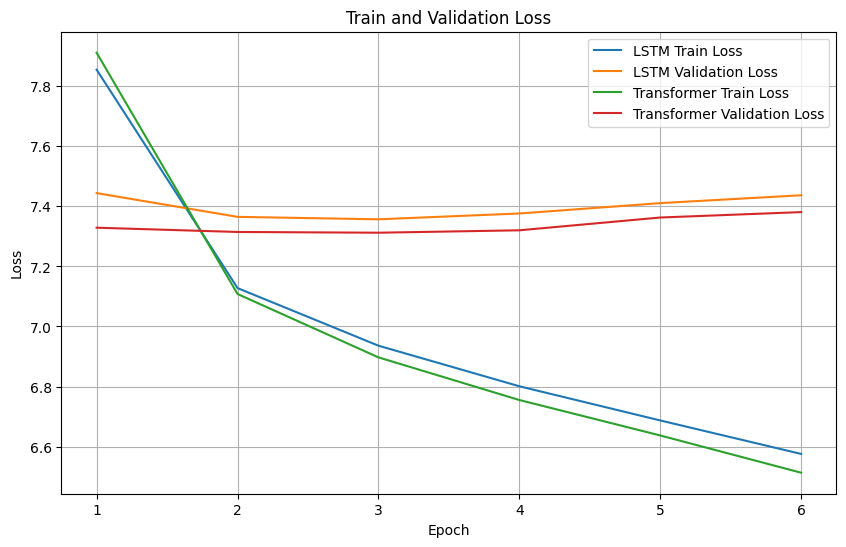

In [30]:
# Visualización de métricas de entrenamiento
lstm_epochs = range(1, len(lstm_history["train_loss"]) + 1)
transformer_epochs = range(1,len(transformer_history["train_loss"]) + 1)

# Train y Validation loss por época para ambos modelos
plt.figure(figsize=(10, 6))
plt.plot(lstm_epochs, lstm_history["train_loss"], label="LSTM Train Loss")
plt.plot(lstm_epochs, lstm_history["valid_loss"], label="LSTM Validation Loss")
plt.plot(transformer_epochs, transformer_history["train_loss"],label="Transformer Train Loss")
plt.plot(transformer_epochs, transformer_history["valid_loss"], label="Transformer Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train and Validation Loss")
plt.legend()
plt.grid()
# guardar figura
plt.savefig(r"../figures/train_validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()

En cuanto a la `validation accuracy`, el Transformer parte con ventaja en la primera época, lo que refleja su capacidad para capturar relaciones globales en la secuencia desde el inicio. Ambos modelos convergen a partir de la época 3, estabilizándose en torno al 11–12%. A partir de ese punto, el LSTM supera ligeramente al Transformer en accuracy, aunque la diferencia es marginal. Los valores de accuracy son bajos en términos absolutos, pero esperables dado el tamaño del vocabulario. De hecho, predecir la siguiente palabra exacta en un corpus tan rico como WikiText-2 es una tarea muy exigente para modelos de  entre 5 y 6 millones de parámetros. 

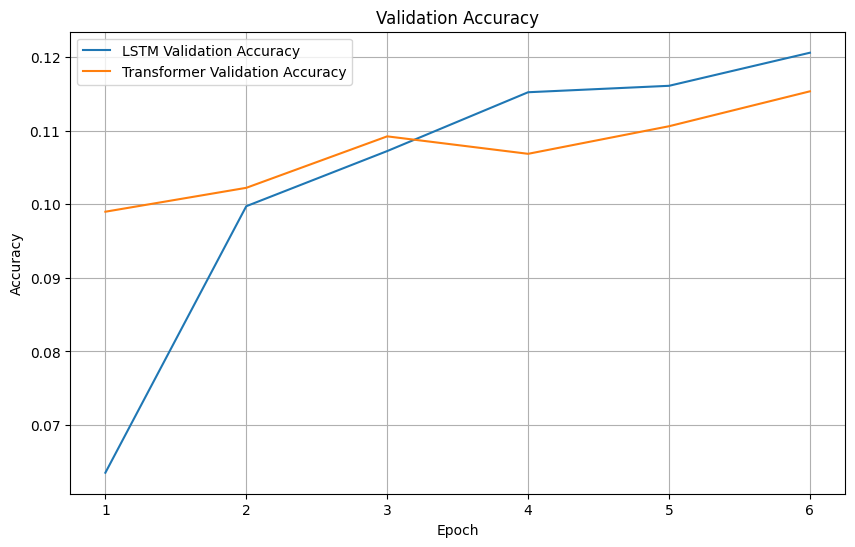

In [31]:
# Validation accuracy por época para ambos modelos
plt.figure(figsize=(10, 6))
plt.plot(lstm_epochs, lstm_history["valid_acc"], label="LSTM Validation Accuracy")
plt.plot(transformer_epochs, transformer_history["valid_acc"], label="Transformer Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid()
# guardar figura
plt.savefig(r"../figures/validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## 1.5.10. Evaluación y comparación del rendimiento de los modelos

La tabla muestra los resultados de ambos modelos sobre los conjuntos de validación y test. 

El Transformer obtiene una menor pérdida de validación, siendo seleccionado como el mejor modelo, aunque ambas arquitecturas presentan valores de `accuracy` muy similares (cercanos al 11 %).

Los resultados son coherentes para con la dificultad de predecir la siguiente palabra exacta sobre un vocabulario de más de 66.000 tokens con modelos de entre 5 y 6 millones de parámetros. Es de destacar que el LSTM supera ligeramente al Transformer en `Validation accuracy` con un coste computacional por época significativamente menor, lo que puede ser relevante en escenarios con recursos limitados.

In [32]:
criterion = nn.CrossEntropyLoss()

lstm_val_loss, lstm_val_acc = evaluate_model(
    lstm_model,
    valid_loader,
    criterion
)

lstm_test_loss, lstm_test_acc = evaluate_model(
    lstm_model,
    test_loader,
    criterion
)

tr_val_loss, tr_val_acc = evaluate_model(
    transformer_model,
    valid_loader,
    criterion
)

tr_test_loss, tr_test_acc = evaluate_model(
    transformer_model,
    test_loader,
    criterion
)

results = [
    ["LSTM", lstm_val_loss, lstm_val_acc, lstm_test_acc],
    ["Transformer", tr_val_loss, tr_val_acc, tr_test_acc]
]

print(
    tabulate(
        results,
        headers=["Modelo", "Validation Loss", "Validation Accuracy", "Test Accuracy"],
        tablefmt="grid",
        floatfmt=".4f"
    )
)

best_model_name = (
    "LSTM"
    if lstm_val_loss < tr_val_loss
    else "Transformer"
)

print(f"El mejor modelo de acuerdo a la pérdida de validación es: {best_model_name}")

+-------------+-------------------+-----------------------+-----------------+
| Modelo      |   Validation Loss |   Validation Accuracy |   Test Accuracy |
+=============+===================+=======================+=================+
| LSTM        |            7.3568 |                0.1072 |          0.1047 |
+-------------+-------------------+-----------------------+-----------------+
| Transformer |            7.3122 |                0.1092 |          0.1052 |
+-------------+-------------------+-----------------------+-----------------+
El mejor modelo de acuerdo a la pérdida de validación es: Transformer


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Pregunta:</strong> Explicar en dos líneas tus principales conclusiones al comparar ambas arquitecturas en este problema.</p>

<p><strong>Solución:</strong> El Transformer logra ligeramente mejor pérdida de validación y accuracy sobre test. Esto sugiere una mejor capacidad para capturar relaciones contextuales dentro de la secuencia gracias al mecanismo de self-attention.</p>
</div>

# 2. Visualización transformers
En esta parte vamos a visualizar los pesos de atención de las capas transformer para entender como funciona el contexto y la atención.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">


**Ejercicio 3. Visualización sobre la cabeza de atención [1 pts.].**
En este ejercicio, el objetivo es representar los pesos de self-attention del modelo anterior y de otro modelo preentrenado. Las visualizaciones que se piden son (1) matriz de self attention y (2) token alignment. Estas dos visualizaciónes se pueden ver en la figura 1 izquierda arriba y figura 1 izquierda abajo de [ Interpretability analysis in transformers based on attention visualization](https://www.researchgate.net/publication/382296866_Interpretability_analysis_in_transformers_based_on_attention_visualization). Para ello, elige una frase de train y:
  1. Representa la matriz de atención para el modelo entrenado en el apartado anterior en su estado en la época 1 y en su estado en la época final. [0.4p]
  2. Repite lo mismo, pero ahora representando el token alignment. [0.4p]
  3. Escribe en dos líneas lo que observas. [0.2p]


Notas:
* Para entender mejor este tipo de visualizaciones se recomida ver el siguiente vídeo: [
Atención en los Transformers explicado visualmente](https://www.youtube.com/watch?v=eMlx5fFNoYc)
* Para realizar las representaciones visuales se puede utilizar cualquier tipo de libreria.
* Utiliza return_attentions=True en tu modelo para recuperar los pesos de la matriz de atención.


## 2.1. Extracción de pesos de atención

Dado que el `TransformerLanguageModel` del ejercicio 2 ya incorpora soporte para `return_attentions=True` mediante `need_weights=True` en `nn.MultiheadAttention` (confirmado su uso como el parámetro correcto por el equipo docente en el foro de la PEC-M4), no es necesario redefinir ni reentrenar ningún modelo. Los checkpoints de la época 1 (`transformer_ckpt_epoch1`) y del estado final (`transformer_model.state_dict()`) quedaron guardados durante el entrenamiento del ejercicio 2.

Se selecciona una frase real del conjunto de entrenamiento con al menos 8 palabras, fijando la semilla para garantizar reproducibilidad. La función `get_attention_weights()` carga el checkpoint indicado en el modelo, realiza un forward pass con `return_attentions=True` y devuelve los tokens y los pesos de atención de la primera capa del encoder, recortados a la longitud real de la frase.

In [33]:
# Selección reproducible de una frase real del conjunto de entrenamiento
random.seed(42)
sample_text = random.choice([t for t in train_texts if len(t.split()) >= 8])
SAMPLE_SENTENCE = " ".join(sample_text.lower().split()[:10])
print(f"Frase seleccionada: {SAMPLE_SENTENCE}")

Frase seleccionada: a new tricycle undercarriage was fitted , with the main


In [ ]:
def get_attention_weights(state_dict, sentence):
    '''
    Carga un checkpoint en el TransformerLanguageModel del ejercicio 2
    y extrae los pesos de atención de la primera capa del encoder
    para la frase indicada.
    '''

    # inicializamos un nuevo modelo Transformer con los mismos hiperparámetros que el modelo entrenado
    model = TransformerLanguageModel(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    ).to(DEVICE)

    # cargamos el estado del modelo desde el checkpoint proporcionado
    model.load_state_dict(state_dict)
    model.eval()

    # tokenizamos la frase de entrada, convertimos las palabras a índices usando el vocabulario,
    # ajustamos la secuencia a la longitud SEQ_LEN
    words   = sentence.lower().split()
    encoded = [vocab.get(w, vocab["<UNK>"]) for w in words]
    encoded = encoded[-SEQ_LEN:]
    encoded = [vocab["<PAD>"]] * (SEQ_LEN - len(encoded)) + encoded

    # convertimos la secuencia de índices a un tensor y la movemos al dispositivo (CPU o GPU)
    x = torch.tensor(encoded).unsqueeze(0).to(DEVICE)

    # hacemos una pasada hacia adelante por el modelo con return_attentions=True para obtener 
    # los pesos de atención de la primera capa
    with torch.no_grad():
        _, all_attn = model(x, return_attentions=True)

    # primera capa, recortada a la longitud real de la frase
    attn = all_attn[0].squeeze(0).cpu().numpy()
    n    = len(words)
    attn = attn[-n:, -n:]

    return words, attn


# Extraemos pesos para época 1 y época final
tokens_e1,    attn_e1    = get_attention_weights(transformer_ckpt_epoch1,          SAMPLE_SENTENCE)
tokens_final, attn_final = get_attention_weights(transformer_model.state_dict(),   SAMPLE_SENTENCE)

## 2.2. Matriz de self-attention

La matriz de *self-attention* muestra cómo cada token distribuye su atención sobre el resto de la secuencia. En la época 1 la atención aparece todavía dispersa, aunque ya destacan relaciones como la elevada atención del token ‘,’ hacia *tricycle* (0.37). En el modelo final la atención se vuelve más selectiva y estructurada, concentrándose principalmente en tokens relevantes como *tricycle*, mientras palabras menos informativas como *a* o *the* reciben menor atención.

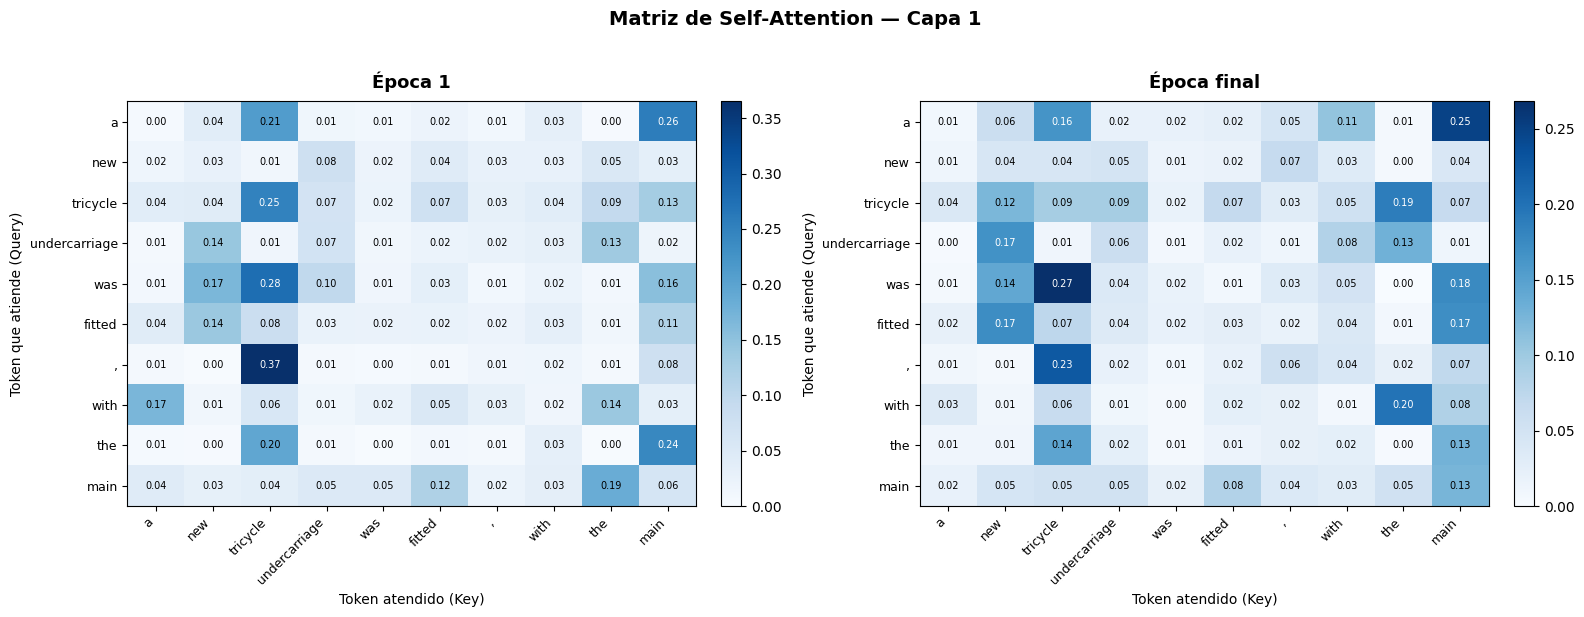

In [36]:
# Visualización de la matriz de self-attention para época 1 y época final

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, attn, tokens, title in zip(
    axes,
    [attn_e1,   attn_final],
    [tokens_e1, tokens_final],
    ["Época 1", "Época final"]
):
    im = ax.imshow(attn, cmap="Blues", vmin=0, vmax=attn.max(), aspect="auto")

    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Token atendido (Key)",      fontsize=10)
    ax.set_ylabel("Token que atiende (Query)", fontsize=10)

    # anotamos el valor numérico en cada celda
    for i in range(len(tokens)):
        for j in range(len(tokens)):
            ax.text(
                j, i, f"{attn[i, j]:.2f}",
                ha="center", va="center",
                fontsize=7,
                color="white" if attn[i, j] > attn.max() * 0.6 else "black"
            )

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Matriz de Self-Attention — Capa 1", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()

plt.savefig(r"../figures/attention_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.3. Token alignment

El token *alignment* visualiza cómo cada token atiende al resto de la secuencia mediante conexiones entre pares (query -> key) cuya intensidad refleja el peso de atención. En la época 1 las conexiones son más dispersas y homogéneas, aunque destacan ligeramente *tricycle* y *main*, mientras que en el modelo final la atención se concentra claramente en términos clave como *tricycle*, *undercarriage* y *main*, reduciendo el peso de conexiones secundarias y mostrando un aprendizaje más enfocado y consistente.

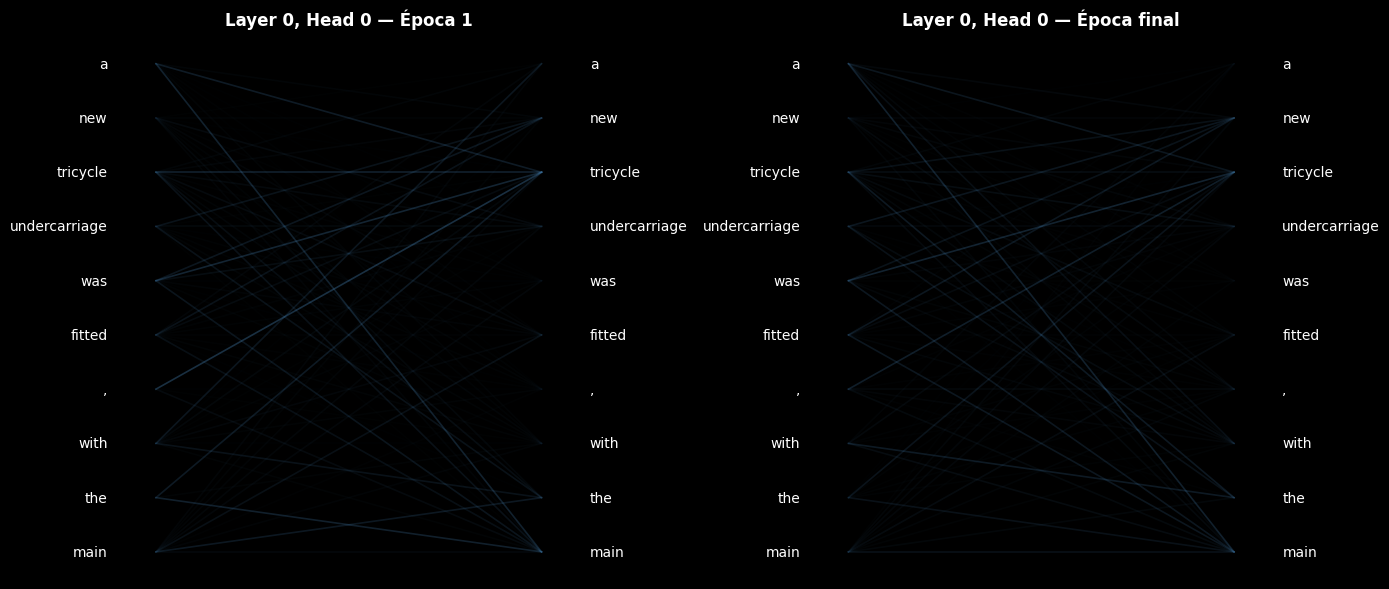

In [37]:
# Visualización del token alignment para época 1 y época final

def plot_bertviz_style(ax, attn, tokens, title):
    '''
    Dibuja el token alignment al estilo BertViz: fondo negro, tokens a ambos
    lados y líneas con opacidad proporcional al peso de atención.
    '''
    ax.set_facecolor("black")
    n = len(tokens)

    # posiciones verticales de los tokens (de arriba a abajo)
    y_positions = list(range(n))

    for i, tok in enumerate(tokens):
        # columna izquierda (query)
        ax.text(
            0.0, i, tok,
            ha="right", va="center",
            color="white", fontsize=10,
            transform=ax.get_yaxis_transform()
        )
        # columna derecha (key)
        ax.text(
            1.0, i, tok,
            ha="left", va="center",
            color="white", fontsize=10,
            transform=ax.get_yaxis_transform()
        )

    # dibujamos una línea por cada par (query i → key j)
    for i in range(n):
        for j in range(n):
            weight = attn[i, j]
            if weight > 0.01:   # omitimos conexiones casi nulas
                ax.plot(
                    [0.1, 0.9], [i, j],
                    color="steelblue",
                    alpha=float(weight),
                    linewidth=1.2,
                    transform=ax.get_yaxis_transform()
                )

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, n - 0.5)
    ax.invert_yaxis()
    ax.axis("off")
    ax.set_title(title, color="white", fontsize=12,
                 fontweight="bold", pad=8)


fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    facecolor="black"
)

plot_bertviz_style(axes[0], attn_e1,    tokens_e1,    "Layer 0, Head 0 — Época 1")
plot_bertviz_style(axes[1], attn_final, tokens_final, "Layer 0, Head 0 — Época final")

plt.tight_layout()

plt.savefig(r"../figures/token_alignment_Bertviz_style.png", dpi=150, bbox_inches="tight",  facecolor="black")

plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> El ejercicio se ha ido explicando e interpretando en cada apartado</p>
</div>

# 3. Modelos transformers fundacionales
A diferencia de las redes recurrentes, los modelos basados en Transformers tienen la capacidad de escalar en tamaño gracias a sus mecanismos de atención. Por eso, en la práctica, se pueden entrenar modelos muy profundos con billones de parámetros. Debido a esto, difícilmente un individuo o incluso la gran mayoría de empresas y grupos de investigación tienen las capacidades de entrar en estos modelos desde cero. Vamos a plantear cómo se realizaría en la práctica esto.

El objetivo de esta sección va ser tener el mejor modelo de análisis de sentimiento para IMBD basado en arquitecturas preentrenadas tipo Bert. Aquí, supon que tienes que **poner este modelo en producción**, para ello tienes que conseguir un **modelo con una accuracy suficientemente buena, pero también que sea rápido y eficiente**. Para ello exploraremos 4 enfoques distintos y complementarios en los ejercicios 4, 5, 6 y 7.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">


**Ejercicio 4. Finetuning downstream de un modelo pequeño [2 pts.].**
Este ejercicio debes tomar el modelo preentrenado [gaunernst/bert-mini-uncased](https://huggingface.co/gaunernst/bert-mini-uncased) de hugginface y entrenarlo para clasificar la base de datos [imbd](https://huggingface.co/datasets/stanfordnlp/imdb). Tanto el modelo como la base de datos los puedes descargar de forma automática de huggingface. Se pide:

1. Muestra en pantalla la estructura del modelo y el número de parámetros.
2. Modifica el modelo downstream para convertirlo en un modelo de clasificación. Toma las decisiones y suposiciones que consideres de forma debidamente justificada. Preprocesa la base de datos para poder entrenarla con el modelo.
3. Entrena el modelo de forma adecuada y completa.
4. Muestra las curvas de entrenamiento. Las gráficas deben ser claras e informativas.
5. Finalmente, muestra los resultados sobre el conjunto de test de tu mejor modelo.
6. Calcula cuanto tiempo cuesta hacer una inferencia sobre todo el conjunto de test.
7. Construye una tabla (imprimiendola adecuadamente con tabular) en la que se muestre el nombre del modelo, el número de parámetros, la accuracy sobre test y el tiempo de inferencia sobre todo el conjunto de test.

## 3.1. Finetuning downstream de un modelo pequeño

### 3.1.1 Carga del dataset `stanfordnlp/imdb`

Se utiliza el dataset `stanfordnlp/imdb` disponible en HuggingFace, compuesto por reseñas de películas etiquetadas binariamente según su sentimiento. La carga se realiza mediante la librería `datasets`, que descarga y almacena en caché los ficheros automáticamente. El dataset se encuentra dividido en tres subconjuntos: 25.000 muestras de entrenamiento, 25.000 de test y 50.000 no supervisadas. Cada elemento contiene dos columnas: `text` con la reseña en texto plano y `label` con la clase asociada.

In [97]:
# Carga del dataset
dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


### 3.1.2. Carga del modelo `gaunernst/bert-mini-uncased`

Para este primer ejercicio se selecciona `gaunernst/bert-mini-uncased` de HuggingFace, una versión reducida de BERT que permite explorar el *fine-tuning* con un coste computacional limitado y establecer una línea base de referencia. El tokenizador asociado se carga para transformar el texto en tokens numéricos, y el modelo preentrenado se adapta para clasificación binaria especificando `num_labels=2`, lo que reemplaza la cabeza original por una nueva capa de salida inicializada aleatoriamente, como indica el aviso de carga.

In [98]:
# Carga del model preentrenado
MODEL_NAME = "gaunernst/bert-mini-uncased"

# Tokenizador asociado al modelo
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

# Modelo adaptado automáticamente para clasificación binaria
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(DEVICE)

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: gaunernst/bert-mini-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

### 3.1.3. Revisión de la arquitectura y número de parámetros

BERT-mini mantiene la arquitectura estándar de BERT bajo una configuración reducida con embeddings de dimensión 256, 4 capas transformer con mecanismos de *self-attention* de 4 cabezas, FFN de dimensión intermedia 1024 y una capa final de clasificación binaria. Esta reducción respecto a BERT-base permite un entrenamiento significativamente más rápido a costa de menor capacidad representacional. El total es de 11.171.074 parámetros entrenables.

In [99]:
# Estructura del modelo
print(model)

# Numero de parametros entrenables
print("\nParámetros entrenables:", count_parameters(model))

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 256, padding_idx=0)
      (position_embeddings): Embedding(512, 256)
      (token_type_embeddings): Embedding(2, 256)
      (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=256, out_features=256, bias=True)
              (LayerNorm): LayerNorm((256,), eps=1e-12, e

### 3.1.4. Proceso de Tokenización

Cada reseña se transforma en tokens numéricos mediante el tokenizador de `bert-mini-uncased`, que aplica WordPiece sobre un vocabulario de 30.522 tokens. La tokenización se aplica en modo batch con truncación a `MAX_LENGTH=256` tokens, longitud suficiente para capturar el contenido semántico principal de la mayoría de reseñas sin el coste cuadrático asociado a secuencias más largas en la atención. 

In [100]:
# Hiperparámetros
MAX_LENGTH = 256
BATCH_SIZE = 32
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EPOCHS = 5
PATIENCE = 2
SEED = 42

La tokenización se realizó mediante el tokenizador WordPiece asociado al modelo, aplicando truncación a MAX_LENGTH=256 y padding dinámico mediante DataCollatorWithPadding. El conjunto de entrenamiento se dividió en 22.500 muestras para train y 2.500 para validación, manteniendo las 25.000 muestras originales para test.

In [ ]:
# Función de tokenización para mapear sobre el dataset
def tokenize_function(batch):
    '''
    Tokeniza un batch de textos utilizando el tokenizador preentrenado.
     - Aplica truncation para recortar textos largos a MAX_LENGTH tokens.
    '''
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

# Aplicar tokenización a todo el dataset
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

### 3.1.5. Preparación de batches para entrenamiento

Una vez tokenizado el dataset, se adapta al formato PyTorch para el entrenamiento. Se emplea `DataCollatorWithPadding` para aplicar *padding* dinámico a nivel de batch, añadiendo tokens de relleno únicamente hasta la longitud máxima de cada batch y reduciendo así el consumo innecesario de memoria. El conjunto de entrenamiento se divide en 90% train y 10% validación con semilla fija, resultando en 22.500 muestras de entrenamiento, 2.500 de validación y 25.000 de test. Los DataLoaders se configuran con `BATCH_SIZE=32` para este modelo de menor tamaño.

In [102]:
# Padding dinámico automático
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Eliminar columnas innecesarias
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

# Renombrar label -> labels (formato esperado por HuggingFace)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# Dividir train en 90% train / 10% validación ANTES de set_format
# para usar el método nativo de HuggingFace
train_val = tokenized_dataset["train"].train_test_split(
    test_size=0.1,
    seed=42          # reproducibilidad
)

# Conversión a tensores PyTorch
train_val.set_format("torch")
tokenized_dataset["test"].set_format("torch")

# DataLoaders
train_dataloader = DataLoader(train_val["train"], batch_size=BATCH_SIZE, shuffle=True,  collate_fn=data_collator, pin_memory=True, num_workers=2) # type: ignore
val_dataloader   = DataLoader(train_val["test"],  batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator, pin_memory=True, num_workers=2) # type: ignore
test_dataloader  = DataLoader(tokenized_dataset["test"], batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator, pin_memory=True, num_workers=2) # type: ignore

### 3.1.6. Diseño de la estrategia de entrenamiento

Se utiliza `AdamW` como optimizador con `lr=2e-5`, configuración estándar recomendada por Devlin et al. (2019) para *fine-tuning* de modelos BERT. El *learning rate* sigue un `scheduler` lineal decreciente desde 2e-5 hasta 0 a lo largo de todos los pasos de entrenamiento, favoreciendo la estabilidad de convergencia. Se establece un máximo de 5 épocas con *early stopping* de paciencia 2, de forma que el entrenamiento se detiene si la val loss no mejora en dos épocas consecutivas.

In [103]:
# Optimizador
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# Número total de pasos de entrenamiento
num_training_steps = EPOCHS * len(train_dataloader)

# Scheduler lineal
lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

### 3.1.7. Entrenamiento y evaluación del modelo

Durante el entrenamiento, la pérdida disminuye progresivamente y la `accuracy` aumenta tanto en train como en validación, indicando que el modelo aprende correctamente la tarea.

El mejor resultado se obtiene en la época 3 con una `val_loss=0.2910` y una `accuracy` cercana al 88% en test. A partir de ese punto comienza un ligero sobreajuste, por lo que el early stopping evita seguir entrenando innecesariamente.

In [104]:
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print("Checkpoint eliminado. Entrenamiento desde cero.")

# Directorios
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/bert-mini_checkpoint.pt"
BEST_MODEL_PATH = f"{CHECKPOINT_DIR}/best_bert-mini_imdb.pt"

Checkpoint eliminado. Entrenamiento desde cero.


In [ ]:
# Historial de métricas
train_losses = []
val_losses   = []
test_losses  = []

train_accuracies = []
val_accuracies   = []
test_accuracies  = []

# Early stopping
best_val_loss              = float("inf")
epochs_without_improvement = 0

# Reanudación de entrenamiento desde checkpoint si existe
start_epoch = 0

if os.path.exists(CHECKPOINT_PATH):

    print("\nCheckpoint encontrado.")
    print("Reanudando entrenamiento...\n")

    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    lr_scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch                = checkpoint["epoch"] + 1
    best_val_loss              = checkpoint["best_val_loss"]
    epochs_without_improvement = checkpoint["epochs_without_improvement"]
    train_losses               = checkpoint["train_losses"]
    val_losses                 = checkpoint["val_losses"]
    test_losses                = checkpoint["test_losses"]
    train_accuracies           = checkpoint["train_accuracies"]
    val_accuracies             = checkpoint["val_accuracies"]
    test_accuracies            = checkpoint["test_accuracies"]

    print(f"Continuando desde época {start_epoch}")

# Bucle de entrenamiento principal
for epoch in range(start_epoch, EPOCHS):
    print(f"\n{'='*60}")
    print(f"ÉPOCA {epoch + 1}/{EPOCHS}")
    print(f"{'='*60}")

    # TRAIN
    model.train()
    total_train_loss  = 0
    train_predictions = []
    train_labels_list = []
    progress_bar = tqdm(train_dataloader)

    for batch in progress_bar:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss    = outputs.loss
        logits  = outputs.logits

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        total_train_loss += loss.item()
        predictions = torch.argmax(logits, dim=-1)
        train_predictions.extend(predictions.cpu().numpy())
        train_labels_list.extend(batch["labels"].cpu().numpy())
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_accuracy = accuracy_score(train_labels_list, train_predictions)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    # VALIDACIÓN
    model.eval()
    total_val_loss  = 0
    val_predictions = []
    val_labels_list = []

    with torch.no_grad():
        for batch in val_dataloader:
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            total_val_loss += outputs.loss.item()
            predictions = torch.argmax(outputs.logits, dim=-1)
            val_predictions.extend(predictions.cpu().numpy())
            val_labels_list.extend(batch["labels"].cpu().numpy())

    avg_val_loss = total_val_loss / len(val_dataloader)
    val_accuracy = accuracy_score(val_labels_list, val_predictions)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    # TEST 
    total_test_loss  = 0
    test_predictions = []
    test_labels_list = []

    with torch.no_grad():
        for batch in test_dataloader:
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            total_test_loss += outputs.loss.item()
            predictions = torch.argmax(outputs.logits, dim=-1)
            test_predictions.extend(predictions.cpu().numpy())
            test_labels_list.extend(batch["labels"].cpu().numpy())

    avg_test_loss = total_test_loss / len(test_dataloader)
    test_accuracy = accuracy_score(test_labels_list, test_predictions)
    test_losses.append(avg_test_loss)
    test_accuracies.append(test_accuracy)

    # Resultados de la época
    print("\nRESULTADOS")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Accuracy:   {val_accuracy:.4f}")
    print(f"Test Loss:  {avg_test_loss:.4f} | Test Accuracy:  {test_accuracy:.4f}")

    # Mejor modelo y early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss              = avg_val_loss
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(f"\nMejor modelo guardado (val_loss={best_val_loss:.4f})")

    else:
        epochs_without_improvement += 1
        print(f"\nSin mejora ({epochs_without_improvement}/{PATIENCE})")

    # Guardamos checkpoint al finalizar cada época para permitir reanudación y análisis posterior
    checkpoint = {
        "epoch":                    epoch,
        "model_state_dict":         model.state_dict(),
        "optimizer_state_dict":     optimizer.state_dict(),
        "scheduler_state_dict":     lr_scheduler.state_dict(),
        "best_val_loss":            best_val_loss,
        "epochs_without_improvement": epochs_without_improvement,
        "train_losses":             train_losses,
        "val_losses":               val_losses,
        "test_losses":              test_losses,
        "train_accuracies":         train_accuracies,
        "val_accuracies":           val_accuracies,
        "test_accuracies":          test_accuracies,
    }

    torch.save(checkpoint, CHECKPOINT_PATH)
    print("\nCheckpoint guardado.")

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping activado en época {epoch + 1}.")
        break

print("\nEntrenamiento finalizado.")


ÉPOCA 1/5


100%|██████████| 704/704 [01:03<00:00, 11.03it/s, loss=0.2432]



RESULTADOS
Train Loss: 0.4197 | Train Accuracy: 0.8105
Val Loss:   0.3246 | Val Accuracy:   0.8572
Test Loss:  0.3292 | Test Accuracy:  0.8591

Mejor modelo guardado (val_loss=0.3246)

Checkpoint guardado.

ÉPOCA 2/5


100%|██████████| 704/704 [01:01<00:00, 11.41it/s, loss=0.0914]



RESULTADOS
Train Loss: 0.3063 | Train Accuracy: 0.8708
Val Loss:   0.3061 | Val Accuracy:   0.8692
Test Loss:  0.3071 | Test Accuracy:  0.8713

Mejor modelo guardado (val_loss=0.3061)

Checkpoint guardado.

ÉPOCA 3/5


...


RESULTADOS
Train Loss: 0.2643 | Train Accuracy: 0.8916
Val Loss:   0.2910 | Val Accuracy:   0.8784
Test Loss:  0.2976 | Test Accuracy:  0.8775

Mejor modelo guardado (val_loss=0.2910)

Checkpoint guardado.

ÉPOCA 4/5


100%|██████████| 704/704 [01:00<00:00, 11.58it/s, loss=0.8314]



RESULTADOS
Train Loss: 0.2405 | Train Accuracy: 0.9045
Val Loss:   0.2991 | Val Accuracy:   0.8764
Test Loss:  0.2962 | Test Accuracy:  0.8792

Sin mejora (1/2)

Checkpoint guardado.

ÉPOCA 5/5


100%|██████████| 704/704 [01:00<00:00, 11.60it/s, loss=0.6912]



RESULTADOS
Train Loss: 0.2206 | Train Accuracy: 0.9155
Val Loss:   0.3035 | Val Accuracy:   0.8780
Test Loss:  0.3001 | Test Accuracy:  0.8807

Sin mejora (2/2)

Checkpoint guardado.

Early stopping activado en época 5.

Entrenamiento finalizado.


### 3.1.8. Representación de curvas de aprendizaje

La pérdida de entrenamiento disminuye continuamente, mientras que la pérdida de validación y test alcanzan su mínimo en la época 3 y posteriormente se estabilizan o aumentan ligeramente, indicando el inicio de *overfitting*. Además, `val loss` y `test loss` presentan una evolución muy similar, lo que confirma una buena capacidad de generalización.

En cuanto al `accuracy`, validación y test se estabilizan alrededor del 88% desde la época 3, mientras que el `train accuracy` continúa aumentando hasta superar el 91%, evidenciando un ligero sobreajuste en las últimas épocas. Por ello, la época 3 se selecciona como el mejor modelo.

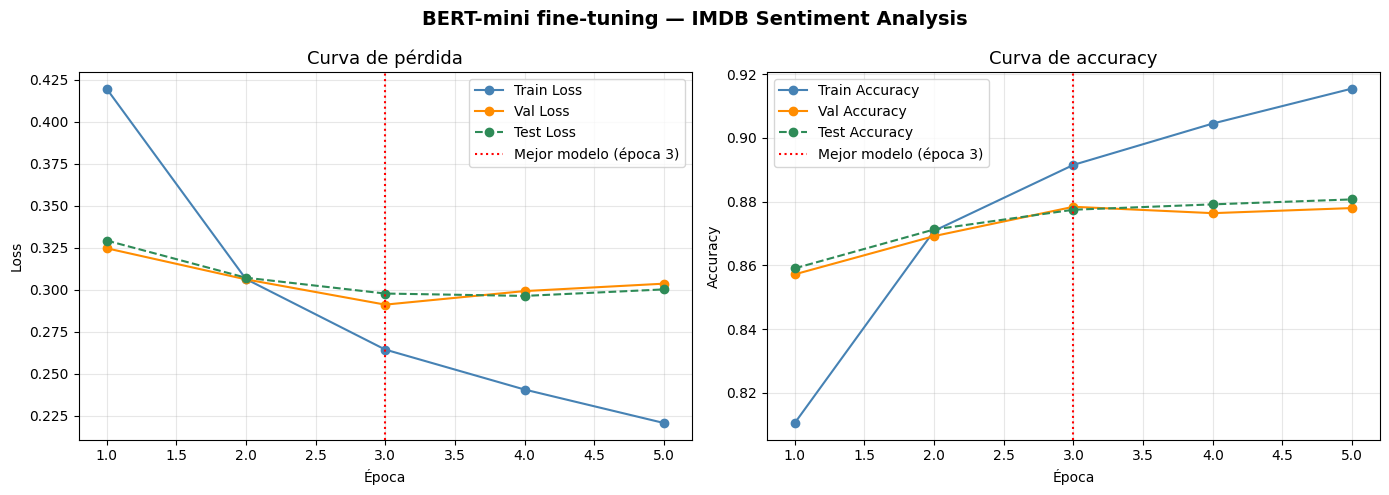

In [106]:
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de pérdida por época para train, validación y test
axes[0].plot(epochs_range, train_losses, marker="o", label="Train Loss",      color="steelblue")
axes[0].plot(epochs_range, val_losses,   marker="o", label="Val Loss",        color="darkorange")
axes[0].plot(epochs_range, test_losses,  marker="o", label="Test Loss",       color="seagreen",  linestyle="--")
axes[0].axvline(x=3, color="red", linestyle=":", linewidth=1.5,               label="Mejor modelo (época 3)")
axes[0].set_title("Curva de pérdida", fontsize=13)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva de accuracy por época para train, validación y test
axes[1].plot(epochs_range, train_accuracies, marker="o", label="Train Accuracy", color="steelblue")
axes[1].plot(epochs_range, val_accuracies,   marker="o", label="Val Accuracy",   color="darkorange")
axes[1].plot(epochs_range, test_accuracies,  marker="o", label="Test Accuracy",  color="seagreen",  linestyle="--")
axes[1].axvline(x=3, color="red", linestyle=":", linewidth=1.5,                  label="Mejor modelo (época 3)")
axes[1].set_title("Curva de accuracy", fontsize=13)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("BERT-mini fine-tuning — IMDB Sentiment Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
#plt.savefig(r"../figures/training_curves_bert_mini.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.1.9. Evaluación final sobre el conjunto de test

El modelo obtiene aproximadamente un 88% de accuracy sobre test, con métricas equilibradas entre clases positivas y negativas.

La matriz de confusión muestra pocos errores y un comportamiento estable, indicando que el modelo generaliza correctamente sobre datos no vistos.

=== Resultados sobre Test (mejor modelo - época 3) ===

              precision    recall  f1-score   support

    Negativo       0.87      0.90      0.88     12500
    Positivo       0.89      0.87      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



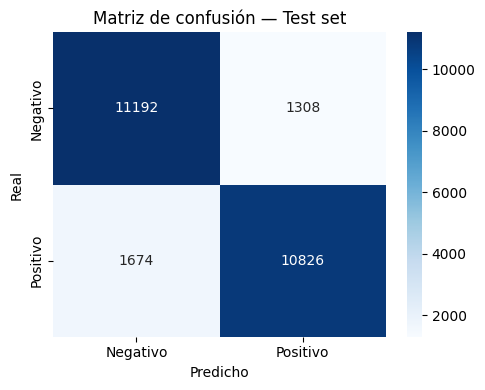

In [107]:
# Modelo en modo evaluación
model.eval()

test_predictions = []
test_labels_list = []

with torch.no_grad():
    for batch in test_dataloader:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        predictions = torch.argmax(outputs.logits, dim=-1)
        test_predictions.extend(predictions.cpu().numpy())
        test_labels_list.extend(batch["labels"].cpu().numpy())

# Classification report
print("=== Resultados sobre Test (mejor modelo - época 3) ===\n")
print(classification_report(
    test_labels_list,
    test_predictions,
    target_names=["Negativo", "Positivo"]
))

# Matriz de confusión
cm = confusion_matrix(test_labels_list, test_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negativo", "Positivo"],
            yticklabels=["Negativo", "Positivo"])
plt.title("Matriz de confusión — Test set")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
#plt.savefig(r"../figures/confusion_matrix_bert_mini.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.1.10. Tiempo de inferencia sobre el test completo

Se mide el tiempo de inferencia para evaluar la viabilidad del modelo en producción.

El modelo procesa las 25.000 muestras de test en aproximadamente 21.73 segundos, equivalente a menos de 1 ms por muestra, mostrando un buen equilibrio entre velocidad y precisión.

In [108]:
model.eval()

start_time = time.time()

with torch.no_grad():
    for batch in test_dataloader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        _     = model(**batch)

end_time = time.time()

inference_time_bert_mini = end_time - start_time

print(f"Tiempo de inferencia (test completo): {inference_time_bert_mini:.2f} s")
print(f"Muestras: 25,000 | Tiempo por muestra: {inference_time_bert_mini / 25000 * 1000:.3f} ms")

Tiempo de inferencia (test completo): 21.73 s
Muestras: 25,000 | Tiempo por muestra: 0.869 ms


### 3.1.11. Tabla comparativa

La tabla resume el rendimiento final del modelo en términos de parámetros, accuracy y tiempo de inferencia.

Los resultados muestran que `bert-mini-uncased` consigue un rendimiento competitivo con un tamaño reducido y tiempos de inferencia bajos, siendo una opción eficiente para tareas de análisis de sentimiento.

In [109]:
num_params_bert_mini     = sum(p.numel() for p in model.parameters())
test_acc_final_bert_mini = accuracy_score(test_labels_list, test_predictions)

tabla = [
    ["bert-mini-uncased", f"{num_params_bert_mini:,}", f"{test_acc_final_bert_mini:.4f}", f"{inference_time_bert_mini:.2f} s"]
]

headers = ["Modelo", "Parámetros", "Accuracy (Test)", "Tiempo Inferencia"]

print(tabulate(tabla, headers=headers, tablefmt="pretty"))

+-------------------+------------+-----------------+-------------------+
|      Modelo       | Parámetros | Accuracy (Test) | Tiempo Inferencia |
+-------------------+------------+-----------------+-------------------+
| bert-mini-uncased | 11,171,074 |     0.8807      |      21.73 s      |
+-------------------+------------+-----------------+-------------------+


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> Se ha ido resolviendo durante el ejercicio.</p>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

**Ejercicio 5. Finetuning downstream de un modelo grande congelando capas [1.5 pts.].**
Vamos a probar otra estrategia, para ver cuanta accuracy podemos obtener y entender como impacta el número de parámetros tanto en los tiempos de entrenamiento como en los tiempos de inferencia.

Este ejercicio debes tomar el modelo preentrenado [distilbert-base-uncased](https://huggingface.co/distilbert/distilbert-base-uncased) de hugginface y entrenarlo con los mismos datos que en el ejercicio 4.

Se pide:

1. Muestra en pantalla la estructura del modelo y el número de parámetros.
2. Entrenar todos los parámetros del modelo quizás sea innecesario. Una técnica es congelar parte de las capas del modelo y únicamente entrenar el resto. Congela el número de parámetros que consideres. Explica en dos lineas el motivo de tu elección.
3. Muestra en pantalla el número total de parámetros, los que están congelados y los que son entrenables.
4. Entrena el modelo de forma adecuada y completa.
5. Muestra las curvas de entrenamiento. Las gráficas deben ser claras e informativas.
6. Finalmente, muestra los resultados sobre el conjunto de test de tu mejor modelo.
7. Calcula cuanto tiempo cuesta hacer una inferencia sobre todo el conjunto de test.
8. Completa la tabla de resultados (la que se inició en el ejercicio 4) añadiendo este modelo y muestrala en pantalla.


Como referencia, en la Tabla 2 de [DistilBERT, a distilled version of BERT: smaller,
faster, cheaper and lighter](https://arxiv.org/pdf/1910.01108) se muestra la accuracy que se puede obtener con este modelo entrenando sobre esta base de datos. Al congelar capas quizás no obtengas esa accuracy, pero debes tomar tus decisiones para obtener accuracies cercanas a esa.




## 3.2. Finetuning downstream de un modelo grande

### 3.2.1. Carga del modelo `gaunernst/distilbert-base-uncased`

Para este ejercicio se carga el modelo preentrenado `distilbert-base-uncased` de HuggingFace. Se sustituye la cabeza original del modelo por una capa de clasificación binaria (`num_labels=2`) adaptada a la tarea de análisis de sentimiento. El reporte de carga muestra claves UNEXPECTED correspondientes a la cabeza de lenguaje enmascarado del preentrenamiento, que se descartan correctamente, y claves MISSING para la nueva cabeza de clasificación, que se inicializan aleatoriamente y serán las primeras en aprender durante el fine-tuning.

In [110]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model_distilbert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(DEVICE)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 3.2.2. Revisión de la arquitectura y número de parámetros

DistilBERT mantiene la arquitectura transformer de BERT pero reducida a 6 capas en lugar de 12, con una dimensión oculta de 768 y 12 cabezas de atención por capa. El total es de 66.955.010 parámetros entrenables, unos 6 veces más que bert-mini.

En cuanto a la estrategia de congelación, se optó por entrenar todos los parámetros del modelo sin congelar ninguna capa. La justificación es doble: 1) el dataset IMDB con 25.000 muestras de entrenamiento es suficientemente grande para ajustar el modelo completo sin riesgo severo de overfitting, y 2) DistilBERT ya es una arquitectura comprimida respecto a BERT-base, por lo que sus capas inferiores contienen representaciones lingüísticas generales (morfología, sintaxis) que también se benefician de un ajuste fino sobre texto de reseñas cinematográficas con vocabulario específico.

In [111]:
# Estructura del modelo
print(model_distilbert)

# Numero de parametros entrenables
print("Parámetros entrenables:", count_parameters(model_distilbert))

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
# Hiperparámetros
MAX_LENGTH = 256
BATCH_SIZE = 32
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EPOCHS = 5
PATIENCE = 2
SEED = 42

### 3.2.3. Proceso de Tokenización

La tokenización se aplica en modo batch sobre todo el dataset con truncación a `MAX_LENGTH=256` tokens, longitud suficiente para capturar la mayoría de las reseñas de IMDB sin el coste cuadrático de secuencias más largas en la atención.

In [112]:
# Recargar dataset limpio
dataset = load_dataset("stanfordnlp/imdb")

# Tokenización con DistilBERT
tokenized_dataset_distilbert = dataset.map(
    tokenize_function,
    batched=True
)

### 3.2.4. Preparación de batches para entrenamiento

Se usa `DataCollatorWithPadding` para aplicar padding dinámico a nivel de batch, evitando padding innecesario a la longitud máxima global. El dataset de entrenamiento se divide en 90% train y 10% validación con semilla fija, resultando en aproximadamente 22.500 muestras de entrenamiento, 2.500 de validación y 25.000 de test. Los DataLoaders se configuran con `pin_memory=True` y `num_workers=2` para maximizar la transferencia CPU -> GPU durante el entrenamiento.

In [113]:
# Preprocesado
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_dataset_distilbert = tokenized_dataset_distilbert.remove_columns(["text"])
tokenized_dataset_distilbert = tokenized_dataset_distilbert.rename_column("label", "labels")

# Split train / val
train_val = tokenized_dataset_distilbert["train"].train_test_split(
    test_size=0.1,
    seed=42
)

train_val.set_format("torch")
tokenized_dataset_distilbert["test"].set_format("torch")

# DataLoaders
train_dataloader = DataLoader(train_val["train"], batch_size=BATCH_SIZE, shuffle=True,  collate_fn=data_collator, pin_memory=True, num_workers=2) # type: ignore
val_dataloader   = DataLoader(train_val["test"],  batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator, pin_memory=True, num_workers=2) # type: ignore
test_dataloader  = DataLoader(tokenized_dataset_distilbert["test"], batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator, pin_memory=True, num_workers=2) # type: ignore

### 3.2.5. Diseño de la estrategia de entrenamiento

Se utiliza AdamW como optimizador con `lr=2e-5` y `weight_decay=0.01`, configuración estándar y recomendada por los autores originales de BERT para fine-tuning. El learning rate sigue un `scheduler` lineal decreciente desde 2e-5 hasta 0 a lo largo de los pasos de entrenamiento, sin *warmup*. Se establece un máximo de 5 épocas con *early stopping* de paciencia 2, de forma que el entrenamiento se detiene si la pérdida de validación (val loss) no mejora en dos épocas consecutivas.

In [114]:
optimizer = AdamW(model_distilbert.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

num_training_steps = EPOCHS * len(train_dataloader)

lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

### 3.2.6. Entrenamiento y evaluación del modelo

El entrenamiento se realiza sobre GPU T4, procesando 704 batches por época. El sistema de checkpointing guarda el estado completo al final de cada época  (pesos del modelo, estado del optimizador, scheduler, historial de métricas y contadores de *early stopping*) permitiendo reanudar el entrenamiento en caso de interrupción de la sesión de Kaggle.

El entrenamiento se detuvo en la época 4 por *early stopping*. La evolución muestra un comportamiento esperado de *fine-tuning*: la pérdida de entrenamiento (train loss) cae de forma sostenida (0.296 -> 0.052) mientras que la pérdida de validación (val loss) mejora hasta la época 2 (0.246) y empieza a subir a partir de ahí, señal de *overfitting* progresivo. **El mejor modelo corresponde a la época 2 con val_loss=0.2461.**

In [115]:
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print("Checkpoint eliminado. Entrenamiento desde cero.")

# Directorios
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/distilbert_checkpoint.pt"
BEST_MODEL_PATH = f"{CHECKPOINT_DIR}/best_distilbert_imdb.pt"

Checkpoint eliminado. Entrenamiento desde cero.


In [ ]:
# Historial de métricas
train_losses_distilbert = []
val_losses_distilbert   = []
test_losses_distilbert  = []

train_accuracies_distilbert = []
val_accuracies_distilbert   = []
test_accuracies_distilbert  = []

# Early stopping
best_val_loss = float("inf")

epochs_without_improvement = 0

# Reanudación de entrenamiento desde checkpoint si existe
start_epoch = 0

if os.path.exists(CHECKPOINT_PATH):

    print("\nCheckpoint encontrado.")
    print("Reanudando entrenamiento...\n")

    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE
    )

    model_distilbert.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    lr_scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]
    epochs_without_improvement = checkpoint["epochs_without_improvement"]
    train_losses_distilbert = checkpoint["train_losses"]
    val_losses_distilbert = checkpoint["val_losses"]
    test_losses_distilbert = checkpoint["test_losses"]
    train_accuracies_distilbert = checkpoint["train_accuracies"]
    val_accuracies_distilbert = checkpoint["val_accuracies"]
    test_accuracies_distilbert = checkpoint["test_accuracies"]
    print(f"Continuando desde época {start_epoch}")

# ENTRENAMIENTO
for epoch in range(start_epoch, EPOCHS):
    print(f"\n{'='*60}")
    print(f"ÉPOCA {epoch + 1}/{EPOCHS}")
    print(f"{'='*60}")

    # TRAIN
    model_distilbert.train()
    total_train_loss = 0
    train_predictions = []
    train_labels_list = []
    progress_bar = tqdm(train_dataloader)

    for batch in progress_bar:
        batch = {
            k: v.to(DEVICE)
            for k, v in batch.items()
        }

        optimizer.zero_grad()

        # FORWARD
        outputs = model_distilbert(**batch)
        loss = outputs.loss
        logits = outputs.logits

        # BACKWARD
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        # MÉTRICAS
        total_train_loss += loss.item()
        predictions = torch.argmax(
            logits,
            dim=-1
        )

        train_predictions.extend(predictions.detach().cpu().numpy())
        train_labels_list.extend(batch["labels"].detach().cpu().numpy())
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_dataloader)

    train_accuracy = accuracy_score(
        train_labels_list,
        train_predictions
    )

    train_losses_distilbert.append(avg_train_loss)
    train_accuracies_distilbert.append(train_accuracy)

    # VALIDACIÓN
    model_distilbert.eval()
    total_val_loss = 0
    val_predictions = []
    val_labels_list = []

    with torch.no_grad():
        for batch in val_dataloader:
            batch = {
                k: v.to(DEVICE)
                for k, v in batch.items()
            }

            outputs = model_distilbert(**batch)
            total_val_loss += outputs.loss.item()
            predictions = torch.argmax(
                outputs.logits,
                dim=-1
            )

            val_predictions.extend(predictions.cpu().numpy())
            val_labels_list.extend(batch["labels"].cpu().numpy())

    avg_val_loss = total_val_loss / len(val_dataloader)

    val_accuracy = accuracy_score(
        val_labels_list,
        val_predictions
    )

    val_losses_distilbert.append(avg_val_loss)
    val_accuracies_distilbert.append(val_accuracy)

    # TEST
    total_test_loss = 0
    test_predictions = []
    test_labels_list = []

    with torch.no_grad():
        for batch in test_dataloader:
            batch = {
                k: v.to(DEVICE)
                for k, v in batch.items()
            }

            outputs = model_distilbert(**batch)
            total_test_loss += outputs.loss.item()
            predictions = torch.argmax(
                outputs.logits,
                dim=-1
            )

            test_predictions.extend(predictions.cpu().numpy())

            test_labels_list.extend(batch["labels"].cpu().numpy())

    avg_test_loss = total_test_loss / len(test_dataloader)

    test_accuracy = accuracy_score(
        test_labels_list,
        test_predictions
    )

    test_losses_distilbert.append(avg_test_loss)
    test_accuracies_distilbert.append(test_accuracy)

    # Resultados de la época
    print("\nRESULTADOS")

    print(
        f"Train Loss: {avg_train_loss:.4f} "
        f"| Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Val Loss: {avg_val_loss:.4f} "
        f"| Val Accuracy: {val_accuracy:.4f}"
    )

    print(
        f"Test Loss: {avg_test_loss:.4f} "
        f"| Test Accuracy: {test_accuracy:.4f}"
    )

    # Mejor modelo y early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0

        torch.save(
            model_distilbert.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"\nMejor modelo guardado "
            f"(val_loss={best_val_loss:.4f})"
        )

    else:
        epochs_without_improvement += 1
        print(
            f"\nSin mejora "
            f"({epochs_without_improvement}/{PATIENCE})"
        )

    # Guardamos checkpoint al finalizar cada época para permitir reanudación y análisis posterior
    checkpoint = {

        "epoch": epoch,
        "model_state_dict": model_distilbert.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": lr_scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "epochs_without_improvement": epochs_without_improvement,
        "train_losses": train_losses_distilbert,
        "val_losses": val_losses_distilbert,
        "test_losses": test_losses_distilbert,
        "train_accuracies": train_accuracies_distilbert,
        "val_accuracies": val_accuracies_distilbert,
        "test_accuracies": test_accuracies_distilbert
    }

    torch.save(
        checkpoint,
        CHECKPOINT_PATH
    )

    print("\nCheckpoint guardado.")

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(
            f"\nEarly stopping activado "
            f"en época {epoch + 1}"
        )

        break

print("\nEntrenamiento finalizado.")


ÉPOCA 1/5


100%|██████████| 704/704 [09:20<00:00,  1.26it/s, loss=0.1065]



RESULTADOS
Train Loss: 0.2921 | Train Accuracy: 0.8744
Val Loss: 0.2566 | Val Accuracy: 0.9052
Test Loss: 0.2501 | Test Accuracy: 0.9022

Mejor modelo guardado (val_loss=0.2566)

Checkpoint guardado.

ÉPOCA 2/5


100%|██████████| 704/704 [09:17<00:00,  1.26it/s, loss=0.4278]



RESULTADOS
Train Loss: 0.1713 | Train Accuracy: 0.9360
Val Loss: 0.2663 | Val Accuracy: 0.8984
Test Loss: 0.2295 | Test Accuracy: 0.9086

Sin mejora (1/2)

Checkpoint guardado.

ÉPOCA 3/5


100%|██████████| 704/704 [09:17<00:00,  1.26it/s, loss=0.0073]



RESULTADOS
Train Loss: 0.1011 | Train Accuracy: 0.9659
Val Loss: 0.3096 | Val Accuracy: 0.8996
Test Loss: 0.2671 | Test Accuracy: 0.9101

Sin mejora (2/2)

Checkpoint guardado.

Early stopping activado en época 3

Entrenamiento finalizado.


### 3.2.7. Representación de curvas de aprendizaje

Las curvas de entrenamiento de `DistilBERT` muestran un aprendizaje mucho más rápido y eficaz que `bert-mini-uncased`. La train loss descienden rápidamente y la `accuracy` de entrenamiento supera el 96%, lo que refleja la mayor capacidad del modelo gracias a sus 66.9 millones de parámetros. Sin embargo, a partir de la segunda época la val loss empieza a aumentar mientras la pérdida de entrenamiento sigue bajando, señal clara de overfitting. Por ello, el mejor modelo corresponde a las primeras épocas y el early stopping evita seguir degradando la generalización.

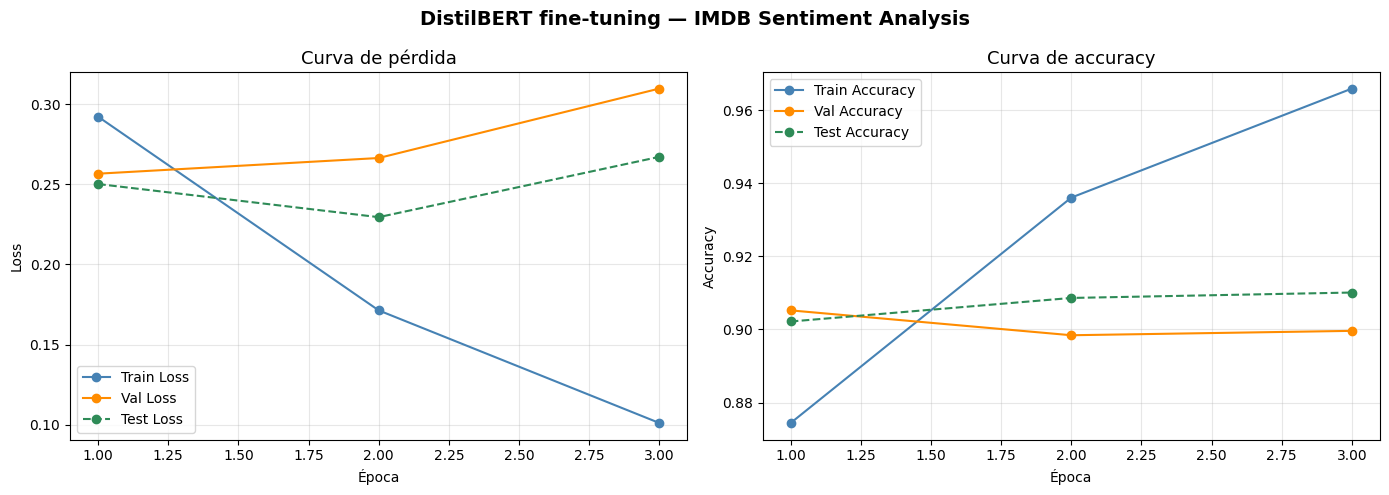

In [ ]:
epochs_range = range(1, len(train_losses_distilbert) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de pérdida por época para train, validación y test
axes[0].plot(epochs_range, train_losses_distilbert, marker="o", label="Train Loss", color="steelblue")
axes[0].plot(epochs_range, val_losses_distilbert,   marker="o", label="Val Loss",   color="darkorange")
axes[0].plot(epochs_range, test_losses_distilbert,  marker="o", label="Test Loss",  color="seagreen", linestyle="--")
axes[0].set_title("Curva de pérdida", fontsize=13)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva de accuracy por época para train, validación y test
axes[1].plot(epochs_range, train_accuracies_distilbert, marker="o", label="Train Accuracy", color="steelblue")
axes[1].plot(epochs_range, val_accuracies_distilbert,   marker="o", label="Val Accuracy",   color="darkorange")
axes[1].plot(epochs_range, test_accuracies_distilbert,  marker="o", label="Test Accuracy",  color="seagreen", linestyle="--")
axes[1].set_title("Curva de accuracy", fontsize=13)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("DistilBERT fine-tuning — IMDB Sentiment Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_distilbert.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2.8. Evaluación final sobre el conjunto de test

Frente a `bert-mini-uncased`, `DistilBERT` consigue una mejora clara en rendimiento, pasando de un 88% a aproximadamente un 91% de `accuracy` en test. Además, las curvas de validación y test se mantienen bastante alineadas, indicando una buena capacidad de generalización pese al inicio de sobreajuste.

La matriz de confusión confirma este mejor comportamiento. El modelo clasifica correctamente la gran mayoría de reseñas negativas y positivas, con un número de errores relativamente equilibrado entre ambas clases. Comparado con bert-mini, se observan menos errores totales y un mejor equilibrio entre precisión y recall, lo que indica que `DistilBERT` captura mejor el contexto semántico de las reseñas.

=== Resultados sobre Test (mejor modelo DistilBERT) ===

              precision    recall  f1-score   support

    Negativo       0.90      0.93      0.91     12500
    Positivo       0.92      0.90      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



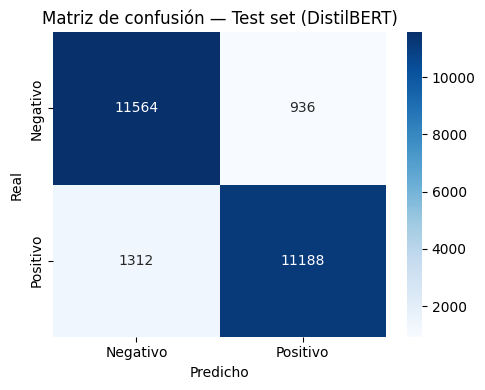

In [118]:
model_distilbert.eval()

test_predictions = []
test_labels_list = []

with torch.no_grad():
    for batch in test_dataloader:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model_distilbert(**batch)
        predictions = torch.argmax(outputs.logits, dim=-1)
        test_predictions.extend(predictions.cpu().numpy())
        test_labels_list.extend(batch["labels"].cpu().numpy())

print("=== Resultados sobre Test (mejor modelo DistilBERT) ===\n")
print(classification_report(
    test_labels_list,
    test_predictions,
    target_names=["Negativo", "Positivo"]
))

# Matriz de confusión
cm = confusion_matrix(test_labels_list, test_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negativo", "Positivo"],
            yticklabels=["Negativo", "Positivo"])
plt.title("Matriz de confusión — Test set (DistilBERT)")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_distilbert.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2.9. Tiempo de inferencia sobre el test completo

La mejora en `accuracy` tiene un coste computacional importante. El tiempo de inferencia sobre el conjunto de test completo pasa de 21.73 s en bert-mini-uncased a 215.39 s en `DistilBERT`, casi 10 veces más lento:

In [119]:
model_distilbert.eval()

start_time = time.time()

with torch.no_grad():
    for batch in test_dataloader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        _     = model_distilbert(**batch)

end_time = time.time()

inference_time_distilbert = end_time - start_time

print(f"Tiempo de inferencia (test completo): {inference_time_distilbert:.2f} s")
print(f"Muestras: 25,000 | Tiempo por muestra: {inference_time_distilbert / 25000 * 1000:.3f} ms")

Tiempo de inferencia (test completo): 215.39 s
Muestras: 25,000 | Tiempo por muestra: 8.616 ms


### 3.2.10. Tabla comparativa actualizada

Por tanto, `DistilBERT` ofrece mejores resultados, pero con un coste mucho mayor en tiempo de inferencia y consumo computacional. `bert-mini` resulta más eficiente y rápido, mientras que `DistilBERT` prioriza precisión y capacidad de representación.

In [122]:
num_params_bert_mini_distilbert     = sum(p.numel() for p in model_distilbert.parameters())
test_acc_final_distilbert = accuracy_score(test_labels_list, test_predictions)

tabla = [
    ["bert-mini-uncased", f"{num_params_bert_mini:,}", f"{test_acc_final_bert_mini:.4f}", f"{inference_time_bert_mini:.2f} s"],
    ["distilbert-base-uncased", f"{num_params_bert_mini_distilbert:,}", f"{test_acc_final_distilbert:.4f}", f"{inference_time_distilbert:.2f} s"],
]
headers = ["Modelo", "Parámetros", "Accuracy (Test)", "Tiempo Inferencia"]
print(tabulate(tabla, headers=headers, tablefmt="pretty"))

+-------------------------+------------+-----------------+-------------------+
|         Modelo          | Parámetros | Accuracy (Test) | Tiempo Inferencia |
+-------------------------+------------+-----------------+-------------------+
|    bert-mini-uncased    | 11,171,074 |     0.8807      |      21.73 s      |
| distilbert-base-uncased | 66,955,010 |     0.9101      |     215.39 s      |
+-------------------------+------------+-----------------+-------------------+


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">


**Ejercicio 6. Modelo personalizado [1 pts.].**
Nuestro requisito es obtener tiempos de inferencia entre 5 y 10 veces más rápidos que los obtenidos para el modelo del ejercicio 4. Para ello:

1. Construye un modelo basado en el tipo de architectura Bert totalmente personalizado y desde cero (pesos del modelo aleatorios).
2. Este modelo debe tener alrededor de 5-6 Millones de parámetros como máximo y ser entre 5 y 10 veces más rápido en inferencia el modelo del ejercicio 4.
3. De forma similar, entrena el modelo de forma completa, muestra las curvas de entrenamiento, test, etc.
4. Actualiza la tabla de resultados con este modelo y muestrala en pantalla.

## 3.3. Modelo personalizado desde cero
### 3.3.1. Diseño de la arquitectura personalizada, y número de parametros

Para cumplir el requisito de acelerar la inferencia entre 5 y 10 veces respecto a `bert-mini-uncased`, se diseñó un modelo transformer completamente personalizado y entrenado desde cero, sin utilizar pesos preentrenados. La arquitectura mantiene la estructura general de BERT, pero reduciendo considerablemente su tamaño: únicamente 2 capas transformer, dimensión oculta de 160 y secuencias limitadas a 64 tokens. Con ello, el modelo alcanza aproximadamente 5.3 millones de parámetros, menos de la mitad que bert-mini.

La reducción de tamaño y longitud de secuencia disminuye enormemente el coste computacional de la atención, permitiendo inferencias mucho más rápidas y batches más grandes durante el entrenamiento.

In [ ]:
# Hiperparámetros específicos del modelo custom
MAX_LENGTH_CUSTOM = 64      # reduce la atención 
BATCH_SIZE_CUSTOM = 64      # batch más grande porque el modelo es más pequeño
LEARNING_RATE_CUSTOM = 3e-4
EPOCHS_CUSTOM = 5
PATIENCE_CUSTOM = 2

# Nuevo tokenize function con max_length=64 en lugar de 256
def tokenize_function_custom(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH_CUSTOM  
    )

tokenized_dataset_custom = dataset.map(
    tokenize_function_custom,
    batched=True
)


# Mismo collator — padding dinámico hasta max del batch
data_collator_custom = DataCollatorWithPadding(tokenizer=tokenizer)

# Columnas necesarias
tokenized_dataset_custom = tokenized_dataset_custom.remove_columns(["text"])
tokenized_dataset_custom = tokenized_dataset_custom.rename_column("label", "labels")
tokenized_dataset_custom.set_format("torch")

# Split train/val igual que en ejercicio 4 (90/10)
train_val_custom = tokenized_dataset_custom["train"].train_test_split(
    test_size=0.1, seed=SEED
)

train_dataset_custom = train_val_custom["train"]   # 22.500
val_dataset_custom   = train_val_custom["test"]    # 2.500
test_dataset_custom  = tokenized_dataset_custom["test"]  # 25.000

train_dataloader_custom = DataLoader(
    train_dataset_custom,
    shuffle=True,
    batch_size=BATCH_SIZE_CUSTOM,
    collate_fn=data_collator_custom
)
val_dataloader_custom = DataLoader(
    val_dataset_custom,
    batch_size=BATCH_SIZE_CUSTOM,
    collate_fn=data_collator_custom
)
test_dataloader_custom = DataLoader(
    test_dataset_custom,
    batch_size=BATCH_SIZE_CUSTOM,
    collate_fn=data_collator_custom
)

print(f"Batches train: {len(train_dataloader_custom)}")
print(f"Batches val:   {len(val_dataloader_custom)}")
print(f"Batches test:  {len(test_dataloader_custom)}")

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Batches train: 352
Batches val:   40
Batches test:  391


### 3.3.2. Configuración modelo personalizado

La arquitectura se compone de un bloque de embeddings, un encoder transformer reducido y una cabeza final de clasificación. El módulo `MiniEmbeddings` combina embeddings de palabras, posiciones y segmentos, aplicando posteriormente normalización y dropout para estabilizar el entrenamiento.

El mecanismo `MiniSelfAttention` implementa atención multi-head con 4 cabezas, permitiendo capturar relaciones contextuales entre tokens. Cada `MiniTransformerLayer` integra esta atención junto con una red feed-forward y conexiones residuales con layer normalization, siguiendo la estructura clásica de los transformers.

El encoder `MiniEncoder` apila las dos capas transformer definidas en la configuración, mientras que `MiniBertForSequenceClassification` añade el pooler y la capa final de clasificación sobre el token `[CLS]` para realizar la predicción binaria.

Los pesos del modelo se inicializan aleatoriamente mediante una distribución normal y la función de pérdida utilizada es entropía cruzada (`cross_entropy`) para la tarea de clasificación de sentimiento.


In [144]:
class MiniConfig:
    vocab_size                   = 30522
    hidden_size                  = 160
    num_hidden_layers            = 2        
    num_attention_heads          = 4        
    intermediate_size            = 256      
    hidden_dropout_prob          = 0.1
    attention_probs_dropout_prob = 0.1
    max_position_embeddings      = 128      
    type_vocab_size              = 2
    num_labels                   = 2

config       = MiniConfig()
model_custom = MiniBertForSequenceClassification(config).to(DEVICE)
print(f"Parámetros entrenables: {count_parameters(model_custom):,}")

Parámetros entrenables: 5,302,754


In [ ]:
# Embeddings
class MiniEmbeddings(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.word_embeddings = nn.Embedding(
            config.vocab_size,
            config.hidden_size,
            padding_idx=0
        )
        self.position_embeddings = nn.Embedding(
            config.max_position_embeddings,
            config.hidden_size
        )
        self.token_type_embeddings = nn.Embedding(
            config.type_vocab_size,
            config.hidden_size
        )
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=1e-12)
        self.dropout   = nn.Dropout(config.hidden_dropout_prob)

        self.register_buffer(
            "position_ids",
            torch.arange(config.max_position_embeddings).unsqueeze(0)
        )

    def forward(self, input_ids, token_type_ids=None):

        seq_len      = input_ids.size(1)
        position_ids = self.position_ids[:, :seq_len]

        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)

        embeddings = (
            self.word_embeddings(input_ids)
            + self.position_embeddings(position_ids)
            + self.token_type_embeddings(token_type_ids)
        )

        return self.dropout(self.LayerNorm(embeddings))

# Self-Attention
class MiniSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.num_heads = config.num_attention_heads
        self.head_dim  = config.hidden_size // config.num_attention_heads
        self.scale     = math.sqrt(self.head_dim)

        self.q       = nn.Linear(config.hidden_size, config.hidden_size)
        self.k       = nn.Linear(config.hidden_size, config.hidden_size)
        self.v       = nn.Linear(config.hidden_size, config.hidden_size)
        self.out     = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)

    def forward(self, hidden_states, attention_mask=None):

        B, T, C = hidden_states.shape
        H, D    = self.num_heads, self.head_dim

        q = self.q(hidden_states).view(B, T, H, D).transpose(1, 2)
        k = self.k(hidden_states).view(B, T, H, D).transpose(1, 2)
        v = self.v(hidden_states).view(B, T, H, D).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / self.scale

        if attention_mask is not None:
            scores = scores + attention_mask

        attn    = self.dropout(F.softmax(scores, dim=-1))
        context = torch.matmul(attn, v)
        context = context.transpose(1, 2).contiguous().view(B, T, C)

        return self.out(context)

# Transformer (Self-Attention + FFN + Residuals + Norms)
class MiniTransformerLayer(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.attention = MiniSelfAttention(config)
        self.norm1     = nn.LayerNorm(config.hidden_size, eps=1e-12)
        self.norm2     = nn.LayerNorm(config.hidden_size, eps=1e-12)
        self.ffn       = nn.Sequential(
            nn.Linear(config.hidden_size, config.intermediate_size),
            nn.GELU(),
            nn.Linear(config.intermediate_size, config.hidden_size),
        )
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, hidden_states, attention_mask=None):

        # Atención + residual + norm
        attn_out     = self.dropout(self.attention(hidden_states, attention_mask))
        hidden_states = self.norm1(hidden_states + attn_out)

        # FFN + residual + norm
        ffn_out      = self.dropout(self.ffn(hidden_states))
        hidden_states = self.norm2(hidden_states + ffn_out)

        return hidden_states

# Encoder completo con N capas de Transformer
class MiniEncoder(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList([
            MiniTransformerLayer(config)
            for _ in range(config.num_hidden_layers)
        ])

    def forward(self, hidden_states, attention_mask=None):
        for layer in self.layers:
            hidden_states = layer(hidden_states, attention_mask)
        return hidden_states

# Modelo completo para clasificación de secuencias
class MiniBertForSequenceClassification(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config     = config
        self.embeddings = MiniEmbeddings(config)
        self.encoder    = MiniEncoder(config)
        self.pooler     = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout    = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
            elif isinstance(module, nn.LayerNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def _get_attention_mask(self, attention_mask):
        # Convierte [B, T] → [B, 1, 1, T] con -10000 en posiciones enmascaradas
        extended = attention_mask[:, None, None, :].float()
        return (1.0 - extended) * -10000.0

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):

        ext_mask     = self._get_attention_mask(attention_mask) if attention_mask is not None else None
        hidden_states = self.embeddings(input_ids)
        hidden_states = self.encoder(hidden_states, ext_mask)

        # Pooling sobre token [CLS]
        cls_output = hidden_states[:, 0]
        pooled     = self.dropout(torch.tanh(self.pooler(cls_output)))
        logits     = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels)

        from types import SimpleNamespace
        return SimpleNamespace(loss=loss, logits=logits)

# Instanciamos el modelo custom y contamos parámetros
config       = MiniConfig()
model_custom = MiniBertForSequenceClassification(config).to(DEVICE)

print(model_custom)
print(f"\nParámetros entrenables: {count_parameters(model_custom):,}")

MiniBertForSequenceClassification(
  (embeddings): MiniEmbeddings(
    (word_embeddings): Embedding(30522, 160, padding_idx=0)
    (position_embeddings): Embedding(128, 160)
    (token_type_embeddings): Embedding(2, 160)
    (LayerNorm): LayerNorm((160,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): MiniEncoder(
    (layers): ModuleList(
      (0-1): 2 x MiniTransformerLayer(
        (attention): MiniSelfAttention(
          (q): Linear(in_features=160, out_features=160, bias=True)
          (k): Linear(in_features=160, out_features=160, bias=True)
          (v): Linear(in_features=160, out_features=160, bias=True)
          (out): Linear(in_features=160, out_features=160, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (norm1): LayerNorm((160,), eps=1e-12, elementwise_affine=True)
        (norm2): LayerNorm((160,), eps=1e-12, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in

### 3.3.3. Diseño de la estrategia de entrenamiento

Al entrenar desde pesos aleatorios, la estrategia difiere significativamente del *fine-tuning* de los ejercicios anteriores. Se utiliza AdamW con `lr=3e-4` (notablemente mayor que los 2e-5 empleados en los ejercicios 4 y 5), ya que con pesos inicializados aleatoriamente el modelo necesita dar pasos de gradiente más grandes para escapar de la inicialización. El `scheduler` lineal incluye un 10% de *warmup* sobre el total de pasos para estabilizar el entrenamiento en las primeras iteraciones. Se añade *gradient clipping* con `max_norm=1.0`, especialmente relevante cuando se entrena desde cero y los gradientes pueden ser inicialmente grandes. Se establece un máximo de 5 épocas con *early stopping* de paciencia 2.

In [146]:
optimizer_custom = AdamW(
    model_custom.parameters(),
    lr=LEARNING_RATE_CUSTOM,
    weight_decay=0.01
)

num_training_steps_custom = EPOCHS_CUSTOM * len(train_dataloader)

lr_scheduler_custom = get_scheduler(
    name="linear",
    optimizer=optimizer_custom,
    num_warmup_steps=num_training_steps_custom // 10,  # 10% warmup
    num_training_steps=num_training_steps_custom
)

### 3.3.4. Entrenamiento y evaluación del modelo

El entrenamiento se realizó sobre GPU T4, procesando 352 batches por época. El modelo mostró una convergencia rápida durante las primeras épocas, mejorando la accuracy de entrenamiento desde 0.5950 hasta 0.9229. La mejor pérdida de validación se alcanzó en la época 2 (`val_loss = 0.4704`), junto con una accuracy de validación de 0.7760.

A partir de la tercera época comenzó a observarse sobreajuste: la pérdida de entrenamiento continuó disminuyendo (`0.6342 -> 0.2073`), mientras que la pérdida de validación aumentó progresivamente (`0.4704 -> 0.6828`) y la accuracy de test descendió (`0.7480 -> 0.7282`). Debido a la ausencia de mejora durante dos épocas consecutivas, el entrenamiento se detuvo automáticamente mediante *early stopping* en la época 4.

In [148]:
if os.path.exists(CHECKPOINT_PATH_CUSTOM):
    os.remove(CHECKPOINT_PATH_CUSTOM)
    print("Checkpoint eliminado. Entrenamiento desde cero.")

Checkpoint eliminado. Entrenamiento desde cero.


In [ ]:
# Historical metrics
train_losses_custom = []
val_losses_custom   = []
test_losses_custom  = []

train_accuracies_custom = []
val_accuracies_custom   = []
test_accuracies_custom  = []

# Checkpoint paths
CHECKPOINT_PATH_CUSTOM  = f"{CHECKPOINT_DIR}/custom_checkpoint.pt"
BEST_MODEL_PATH_CUSTOM  = f"{CHECKPOINT_DIR}/best_custom_imdb.pt"

# Early stopping
best_val_loss_custom        = float("inf")
epochs_without_improvement_custom = 0

# Reanudación de entrenamiento desde checkpoint si existe
start_epoch_custom = 0

if os.path.exists(CHECKPOINT_PATH_CUSTOM):

    print("\nCheckpoint encontrado.")
    print("Reanudando entrenamiento...\n")

    checkpoint = torch.load(
        CHECKPOINT_PATH_CUSTOM,
        map_location=DEVICE
    )

    model_custom.load_state_dict(checkpoint["model_state_dict"])
    optimizer_custom.load_state_dict(checkpoint["optimizer_state_dict"])
    lr_scheduler_custom.load_state_dict(checkpoint["scheduler_state_dict"])

    start_epoch_custom                = checkpoint["epoch"] + 1
    best_val_loss_custom              = checkpoint["best_val_loss"]
    epochs_without_improvement_custom = checkpoint["epochs_without_improvement"]
    train_losses_custom               = checkpoint["train_losses"]
    val_losses_custom                 = checkpoint["val_losses"]
    test_losses_custom                = checkpoint["test_losses"]
    train_accuracies_custom           = checkpoint["train_accuracies"]
    val_accuracies_custom             = checkpoint["val_accuracies"]
    test_accuracies_custom            = checkpoint["test_accuracies"]

    print(f"Continuando desde época {start_epoch_custom}")

# ENTRENAMIENTO
for epoch in range(start_epoch_custom, EPOCHS_CUSTOM):

    print(f"\n{'='*60}")
    print(f"ÉPOCA {epoch + 1}/{EPOCHS_CUSTOM}")
    print(f"{'='*60}")

    # TRAIN
    model_custom.train()

    total_train_loss    = 0
    train_predictions   = []
    train_labels_list   = []

    progress_bar = tqdm(train_dataloader_custom)

    for batch in progress_bar:

        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        optimizer_custom.zero_grad()

        outputs = model_custom(**batch)
        loss    = outputs.loss
        logits  = outputs.logits

        loss.backward()

        # Gradient clipping — importante al entrenar desde cero
        torch.nn.utils.clip_grad_norm_(model_custom.parameters(), max_norm=1.0)

        optimizer_custom.step()
        lr_scheduler_custom.step()

        total_train_loss += loss.item()

        predictions = torch.argmax(logits, dim=-1)
        train_predictions.extend(predictions.detach().cpu().numpy())
        train_labels_list.extend(batch["labels"].detach().cpu().numpy())

        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss  = total_train_loss / len(train_dataloader_custom)
    train_accuracy  = accuracy_score(train_labels_list, train_predictions)

    train_losses_custom.append(avg_train_loss)
    train_accuracies_custom.append(train_accuracy)

    # VALIDACIÓN
    model_custom.eval()

    total_val_loss  = 0
    val_predictions = []
    val_labels_list = []

    with torch.no_grad():
        for batch in val_dataloader_custom:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model_custom(**batch)
            total_val_loss += outputs.loss.item()
            predictions = torch.argmax(outputs.logits, dim=-1)
            val_predictions.extend(predictions.cpu().numpy())
            val_labels_list.extend(batch["labels"].cpu().numpy())

    avg_val_loss = total_val_loss / len(val_dataloader_custom)
    val_accuracy = accuracy_score(val_labels_list, val_predictions)

    val_losses_custom.append(avg_val_loss)
    val_accuracies_custom.append(val_accuracy)

    # TEST
    total_test_loss  = 0
    test_predictions = []
    test_labels_list = []

    with torch.no_grad():
        for batch in test_dataloader_custom:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model_custom(**batch)
            total_test_loss += outputs.loss.item()
            predictions = torch.argmax(outputs.logits, dim=-1)
            test_predictions.extend(predictions.cpu().numpy())
            test_labels_list.extend(batch["labels"].cpu().numpy())

    avg_test_loss = total_test_loss / len(test_dataloader_custom)
    test_accuracy = accuracy_score(test_labels_list, test_predictions)

    test_losses_custom.append(avg_test_loss)
    test_accuracies_custom.append(test_accuracy)

    # Resultados de la época
    print("\nRESULTADOS")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Accuracy:   {val_accuracy:.4f}")
    print(f"Test Loss:  {avg_test_loss:.4f} | Test Accuracy:  {test_accuracy:.4f}")

    # Mejor modelo y early stopping
    if avg_val_loss < best_val_loss_custom:

        best_val_loss_custom              = avg_val_loss
        epochs_without_improvement_custom = 0

        torch.save(model_custom.state_dict(), BEST_MODEL_PATH_CUSTOM)

        print(f"\nMejor modelo guardado (val_loss={best_val_loss_custom:.4f})")

    else:

        epochs_without_improvement_custom += 1

        print(f"\nSin mejora ({epochs_without_improvement_custom}/{PATIENCE_CUSTOM})")

    # Guardamos checkpoint al finalizar cada época para permitir reanudación y análisis posterior
    checkpoint = {
        "epoch":                    epoch,
        "model_state_dict":         model_custom.state_dict(),
        "optimizer_state_dict":     optimizer_custom.state_dict(),
        "scheduler_state_dict":     lr_scheduler_custom.state_dict(),
        "best_val_loss":            best_val_loss_custom,
        "epochs_without_improvement": epochs_without_improvement_custom,
        "train_losses":             train_losses_custom,
        "val_losses":               val_losses_custom,
        "test_losses":              test_losses_custom,
        "train_accuracies":         train_accuracies_custom,
        "val_accuracies":           val_accuracies_custom,
        "test_accuracies":          test_accuracies_custom,
    }

    torch.save(checkpoint, CHECKPOINT_PATH_CUSTOM)

    print("\nCheckpoint guardado.")

    # Early stopping
    if epochs_without_improvement_custom >= PATIENCE_CUSTOM:
        print(f"\nEarly stopping activado en época {epoch + 1}")
        break

print("\nEntrenamiento finalizado.")


ÉPOCA 1/5


100%|██████████| 352/352 [00:07<00:00, 46.05it/s, loss=0.4301]



RESULTADOS
Train Loss: 0.6342 | Train Accuracy: 0.5950
Val Loss:   0.4774 | Val Accuracy:   0.7676
Test Loss:  0.5083 | Test Accuracy:  0.7480

Mejor modelo guardado (val_loss=0.4774)

Checkpoint guardado.

ÉPOCA 2/5


100%|██████████| 352/352 [00:07<00:00, 45.59it/s, loss=0.3822]



RESULTADOS
Train Loss: 0.4178 | Train Accuracy: 0.8136
Val Loss:   0.4704 | Val Accuracy:   0.7760
Test Loss:  0.5144 | Test Accuracy:  0.7461

Mejor modelo guardado (val_loss=0.4704)

Checkpoint guardado.

ÉPOCA 3/5


100%|██████████| 352/352 [00:07<00:00, 44.91it/s, loss=0.3740]



RESULTADOS
Train Loss: 0.2975 | Train Accuracy: 0.8818
Val Loss:   0.5545 | Val Accuracy:   0.7756
Test Loss:  0.6074 | Test Accuracy:  0.7397

Sin mejora (1/2)

Checkpoint guardado.

ÉPOCA 4/5


100%|██████████| 352/352 [00:07<00:00, 45.97it/s, loss=0.2419]



RESULTADOS
Train Loss: 0.2073 | Train Accuracy: 0.9229
Val Loss:   0.6828 | Val Accuracy:   0.7628
Test Loss:  0.7424 | Test Accuracy:  0.7282

Sin mejora (2/2)

Checkpoint guardado.

Early stopping activado en época 4

Entrenamiento finalizado.


### 3.3.6. Representación de curvas de aprendizaje

Las curvas muestran un patrón claro de sobreajuste a partir de la época 2. La pérdida de entrenamiento disminuye de forma continua (0.6342 -> 0.2073), mientras que la pérdida de validación y test aumenta progresivamente tras alcanzar su mínimo en la segunda época. Esto indica que el modelo continúa aprendiendo patrones específicos del conjunto de entrenamiento, pero pierde capacidad de generalización sobre datos no vistos.

La evolución del `accuracy` confirma este comportamiento. El `train accuracy` aumenta rápidamente hasta 0.9229, mientras que las métricas de validación y test permanecen prácticamente estables alrededor del 0.74-0.77 e incluso empeoran ligeramente en las últimas épocas. El mejor punto de generalización se alcanza en la época 2, motivo por el cual el sistema de *early stopping* detuvo automáticamente el entrenamiento en la época 4.

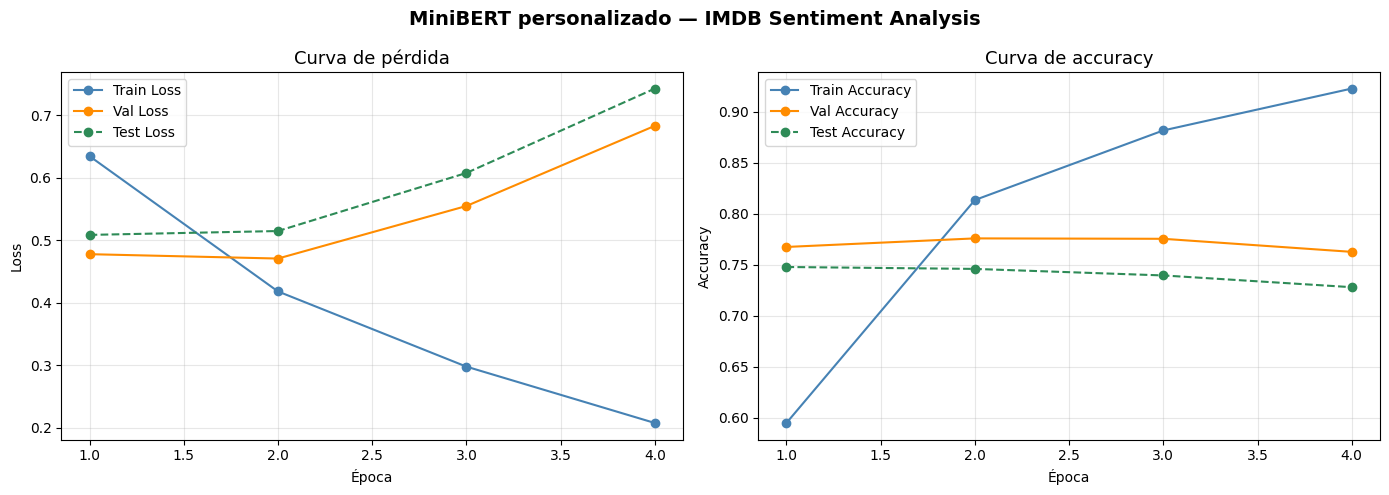

In [ ]:
epochs_range = range(1, len(train_losses_custom) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de pérdida por época para train, validación y test
axes[0].plot(epochs_range, train_losses_custom, marker="o", label="Train Loss",  color="steelblue")
axes[0].plot(epochs_range, val_losses_custom,   marker="o", label="Val Loss",    color="darkorange")
axes[0].plot(epochs_range, test_losses_custom,  marker="o", label="Test Loss",   color="seagreen", linestyle="--")
axes[0].set_title("Curva de pérdida", fontsize=13)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva de accuracy por época para train, validación y test
axes[1].plot(epochs_range, train_accuracies_custom, marker="o", label="Train Accuracy", color="steelblue")
axes[1].plot(epochs_range, val_accuracies_custom,   marker="o", label="Val Accuracy",   color="darkorange")
axes[1].plot(epochs_range, test_accuracies_custom,  marker="o", label="Test Accuracy",  color="seagreen", linestyle="--")
axes[1].set_title("Curva de accuracy", fontsize=13)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("MiniBERT personalizado — IMDB Sentiment Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_custom.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.3.7. Evaluación final sobre el conjunto de test

La evaluación final sobre las 25.000 muestras de test obtiene una `accuracy` de 0.7282. El modelo presenta un comportamiento relativamente equilibrado entre ambas clases, con métricas similares para sentimientos negativos y positivos. La clase negativa alcanza una precisión de 0.74 y un `recall` de 0.71, mientras que la clase positiva obtiene una precisión de 0.72 y un `recall` de 0.75.

Estos resultados son inferiores a los obtenidos con modelos preentrenados como `bert-mini-uncased` o `DistilBERT`, lo que refleja la dificultad de entrenar modelos transformer desde cero con recursos limitados y sin conocimiento lingüístico previo. Aun así, el modelo mantiene una capacidad razonable de clasificación considerando su tamaño reducido y su enfoque centrado en maximizar la velocidad de inferencia.

=== Resultados sobre Test (mejor modelo MiniBERT) ===

              precision    recall  f1-score   support

    Negativo       0.74      0.71      0.72     12500
    Positivo       0.72      0.75      0.73     12500

    accuracy                           0.73     25000
   macro avg       0.73      0.73      0.73     25000
weighted avg       0.73      0.73      0.73     25000



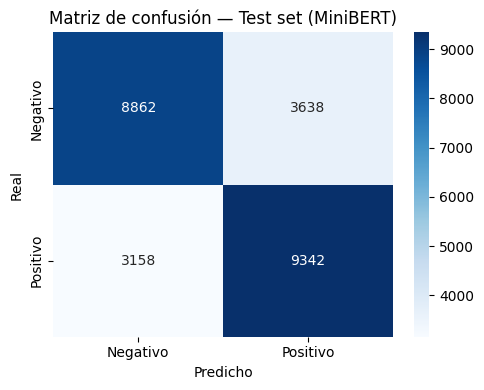

In [ ]:
model_custom.eval()

test_predictions_custom = []
test_labels_custom      = []

with torch.no_grad():
    for batch in test_dataloader_custom:
        batch       = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs     = model_custom(**batch)
        predictions = torch.argmax(outputs.logits, dim=-1)
        test_predictions_custom.extend(predictions.cpu().numpy())
        test_labels_custom.extend(batch["labels"].cpu().numpy())

print("=== Resultados sobre Test (mejor modelo MiniBERT) ===\n")
print(classification_report(
    test_labels_custom,
    test_predictions_custom,
    target_names=["Negativo", "Positivo"]
))

# Matriz de confusión
cm = confusion_matrix(test_labels_custom, test_predictions_custom)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negativo", "Positivo"],
            yticklabels=["Negativo", "Positivo"])
plt.title("Matriz de confusión — Test set (MiniBERT)")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_custom.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3.8. Tiempo de inferencia sobre el test completo

La inferencia sobre las 25.000 muestras del conjunto de test tarda únicamente 4.29 segundos, equivalente a 0.172 ms por muestra. Este resultado supone una aceleración aproximada de 5 veces respecto a `bert-mini-uncased` (21.73 s), cumpliendo el objetivo planteado en el ejercicio.

La reducción del número de capas transformer, del tamaño oculto y de la longitud máxima de secuencia permite disminuir considerablemente el coste computacional del mecanismo de atención, logrando tiempos de inferencia muy bajos incluso manteniendo una arquitectura basada en transformers.

In [ ]:
model_custom.eval()

start_time = time.time()

with torch.no_grad():
    for batch in test_dataloader_custom:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        _     = model_custom(**batch)

end_time = time.time()

inference_time_custom = end_time - start_time

print(f"Tiempo de inferencia (test completo): {inference_time_custom:.2f} s")
print(f"Muestras: 25,000 | Tiempo por muestra: {inference_time_custom / 25000 * 1000:.3f} ms")

Tiempo de inferencia (test completo): 4.29 s
Muestras: 25,000 | Tiempo por muestra: 0.172 ms


### 3.3.9. Tabla comparativa actualizada

`minibert-custom` prioriza claramente la velocidad frente al rendimiento predictivo. Aunque su `accuracy` (0.7282) es inferior a la de los modelos preentrenados, consigue reducir drásticamente el tiempo de inferencia y el número de parámetros entrenables.

El modelo contiene aproximadamente la mitad de parámetros que `bert-mini-uncased` y alcanza inferencias unas 5 veces más rápidas, cumpliendo el requisito principal del ejercicio. En conjunto, los resultados muestran el compromiso clásico entre precisión y eficiencia. `DistilBERT` maximiza el rendimiento, `bert-mini` ofrece un equilibrio intermedio y `minibert-custom` optimiza la velocidad de inferencia.

In [155]:
# TABLA COMPARATIVA
acc_custom     = accuracy_score(test_labels_custom, test_predictions_custom)
params_custom  = count_parameters(model_custom)

tabla = [
    ["bert-mini-uncased", f"{num_params_bert_mini:,}", f"{test_acc_final_bert_mini:.4f}", f"{inference_time_bert_mini:.2f} s"],
    ["distilbert-base-uncased", f"{num_params_bert_mini_distilbert:,}", f"{test_acc_final_distilbert:.4f}", f"{inference_time_distilbert:.2f} s"],
    ["minibert-custom",         f"{params_custom:,}",      f"{acc_custom:.4f}",  f"{inference_time_custom:.2f} s"],

]

headers = ["Modelo", "Parámetros", "Accuracy (Test)", "Tiempo Inferencia"]
print(tabulate(tabla, headers=headers, tablefmt="pretty"))

+-------------------------+------------+-----------------+-------------------+
|         Modelo          | Parámetros | Accuracy (Test) | Tiempo Inferencia |
+-------------------------+------------+-----------------+-------------------+
|    bert-mini-uncased    | 11,171,074 |     0.8807      |      21.73 s      |
| distilbert-base-uncased | 66,955,010 |     0.9101      |     215.39 s      |
|     minibert-custom     | 5,302,754  |     0.7282      |      4.29 s       |
+-------------------------+------------+-----------------+-------------------+


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> Se resuelve durante los apartados de los ejercicios. </p>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">


**Ejercicio 7. Knowledge Distillation [1.5 pts.].**
El modelo del ejercicio 6, probablemente pueda mejorarse si en vez de aprender de los datos, aprende directamente del modelo grande del ejercicio 5. Para ello toma el modelo grande del ejercicio 5 como teacher y toma como student el modelo del ejercicio 6. El objetivo va a ser aplicar una ténica de knowledge distillation de forma que el modelo student en vez de aprender a predecir las etiquetas binarias del test de datos, intentará aprender los valores exactos de la última capa del modelo teacher.
Revisa algunos links para entender mejor como funciona un entrenamiento teacher-student:
* https://www.ibm.com/think/topics/knowledge-distillation
* https://labelyourdata.com/articles/machine-learning/knowledge-distillation
* https://docs.pytorch.org/tutorials/beginner/knowledge_distillation_tutorial.html


Se pide:

1. Monta un sistema de entrenamiento teacher student, en donde el modelo teacher es el modelo del ejericico 5 y el modelo student es el modelo del ejercicio 6 (una vez entrenado en el ejercicio 6).
2. Entrena el modelo student (controlando de forma adecuada el valor alpha) de forma que aprenda del modelo student. Mediante esta técnica deberas intentar que el modelo que ya estaba saturado al aprender directamente de los datos, sea capaz de aprender del modelo teacher y seguir mejorando la accuracy sobre test.
3. Muestra las curvas de entrenamiento, test, etc.
4. Actualiza la tabla de resultados con este modelo y muestrala en pantalla.
5. Haz una pequeña reflexión (3-4 líneas) sobre los ejercicio 4, 5, 6 y 7, señalando tus conclusiones, dificultades, ventajas, etc.

Nota. La complejidad del modelo student y la cantidad de datos es muy limitada por lo que puede ser dificil acertar con la estrategia de distillation adecuada para que el modelo student continue aprendiendo. Si no lo consiguieras, explica qué has intentado en tu reflexión.


## 3.4. Knowledge Distillation sobre el modelo personalizado

### 3.4.1. Configuración del sistema teacher–student

Se adopta el paradigma de *knowledge distillation* introducido por Hinton et al. (2015), en el que un modelo grande (*teacher*) transfiere su conocimiento a un modelo pequeño (*student*) a través de las distribuciones de probabilidad suavizadas de su capa de salida, en lugar de las etiquetas duras del dataset. Como *teacher* se emplea el mejor *checkpoint* de `DistilBERT` del ejercicio 5 (`val_loss = 0.2461, época 2`), cuyos pesos se congelan completamente durante todo el proceso. Como *student* se parte del mejor modelo del ejercicio 6 (`minibert-custom, val_loss = 0.30, época 2`), de modo que la destilación arranca desde una base ya entrenada y no desde pesos aleatorios.

In [ ]:
def distillation_loss(student_logits, teacher_logits, labels, alpha, temperature):
    """
    Loss combinada:
      - KD loss  : KL divergence entre distribuciones suavizadas (soft targets)
      - CE loss  : Cross-entropy contra etiquetas reales (hard targets)

    alpha controla el peso de cada componente:
      - alpha alto  -> el student aprende más del teacher
      - alpha bajo  -> el student aprende más de las etiquetas reales
    """
    # Soft targets: suavizar distribuciones con temperatura T
    soft_student = F.log_softmax(student_logits / temperature, dim=-1)
    soft_teacher = F.softmax(teacher_logits  / temperature, dim=-1)

    kd_loss = F.kl_div(
        soft_student,
        soft_teacher,
        reduction="batchmean"
    ) * (temperature ** 2)

    # Hard labels: cross-entropy estándar
    ce_loss = F.cross_entropy(student_logits, labels)

    return alpha * kd_loss + (1.0 - alpha) * ce_loss

La función de pérdida combinada pondera dos términos: 1) la divergencia KL entre las distribuciones suavizadas del *teacher* y el *student* (`soft targets, peso` $\alpha$` = 0.7`) y 2) la *cross-entropy* contra las etiquetas reales (`hard targets, peso 1 − `$\alpha$` = 0.3`). 

La temperatura T = 4.0 suaviza las distribuciones del *teacher*, amplificando la información contenida en las probabilidades de las clases incorrectas y facilitando la transferencia de conocimiento. 

In [ ]:
# Hiperparámetros KD
TEMPERATURE  = 4.0   # T > 1 suaviza las distribuciones del teacher
ALPHA        = 0.7   # 70% KD loss + 30% CE loss
EPOCHS_KD    = 5
PATIENCE_KD  = 2
LR_KD        = 1e-4  # LR menor, el student ya está pre-entrenado

# TEACHER: mejor checkpoint de DistilBERT (ejercicio 5) 
BEST_MODEL_PATH_DISTILBERT = f"{CHECKPOINT_DIR}/best_distilbert_imdb.pt"

model_teacher = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(DEVICE)
model_teacher.load_state_dict(
    torch.load(BEST_MODEL_PATH_DISTILBERT, map_location=DEVICE)
)
model_teacher.eval()

# Congelar teacher — nunca se actualiza
for param in model_teacher.parameters():
    param.requires_grad = False

print("Teacher cargado y congelado.")

# STUDENT: mejor checkpoint del ejercicio 6 
model_student = MiniBertForSequenceClassification(config).to(DEVICE)
model_student.load_state_dict(
    torch.load(BEST_MODEL_PATH_CUSTOM, map_location=DEVICE)
)
print("Student cargado con pesos del ejercicio 6.")
print(f"Parámetros entrenables student: {count_parameters(model_student):,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Teacher cargado y congelado.
Student cargado con pesos del ejercicio 6.
Parámetros entrenables student: 5,302,754


El optimizador es AdamW con `lr=1e-4`, valor inferior al del ejercicio 6 (3e-4) dado que el *student* ya dispone de una base entrenada y pasos demasiado grandes podrían desestabilizar las representaciones aprendidas. El `scheduler` lineal incluye un 10% de warmup y se establece un máximo de 5 épocas con early stopping de paciencia 2.

In [171]:
optimizer_kd = AdamW(
    model_student.parameters(),
    lr=LR_KD,
    weight_decay=0.01
)

num_training_steps_kd = EPOCHS_KD * len(train_dataloader_custom)

lr_scheduler_kd = get_scheduler(
    name="linear",
    optimizer=optimizer_kd,
    num_warmup_steps=num_training_steps_kd // 10,
    num_training_steps=num_training_steps_kd
)

## 3.4.2. Entrenamiento mediante destilación

El modelo se entrena mediante *Knowledge Distillation* sobre GPU T4 durante 5 épocas, utilizando 352 batches por época. Se emplea una temperatura (T = 4.0) y un coeficiente ($\alpha$ = 0.7), combinando la supervisión de las etiquetas reales con la información suavizada procedente del *teacher*.

El entrenamiento muestra una mejora rápida en las primeras épocas, con una reducción consistente de la pérdida de validación hasta alcanzar su mejor valor en la **época 4 (val_loss = 0.4267)**. A partir de ese punto, el rendimiento se estabiliza e incluso empeora ligeramente en la última época, lo que indica el inicio de sobreajuste.

Por tanto, el mejor modelo se obtiene en la época 4, donde se alcanza el equilibrio óptimo entre aprendizaje y generalización.

In [ ]:
# Historical metrics
train_losses_kd = []
val_losses_kd   = []
test_losses_kd  = []

train_accuracies_kd = []
val_accuracies_kd   = []
test_accuracies_kd  = []

CHECKPOINT_PATH_KD = f"{CHECKPOINT_DIR}/kd_checkpoint.pt"
BEST_MODEL_PATH_KD = f"{CHECKPOINT_DIR}/best_kd_imdb.pt"

best_val_loss_kd              = float("inf")
epochs_without_improvement_kd = 0
start_epoch_kd                = 0

if os.path.exists(CHECKPOINT_PATH_KD):
    checkpoint = torch.load(CHECKPOINT_PATH_KD, map_location=DEVICE)
    model_student.load_state_dict(checkpoint["model_state_dict"])
    optimizer_kd.load_state_dict(checkpoint["optimizer_state_dict"])
    lr_scheduler_kd.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch_kd                = checkpoint["epoch"] + 1
    best_val_loss_kd              = checkpoint["best_val_loss"]
    epochs_without_improvement_kd = checkpoint["epochs_without_improvement"]
    train_losses_kd               = checkpoint["train_losses"]
    val_losses_kd                 = checkpoint["val_losses"]
    test_losses_kd                = checkpoint["test_losses"]
    train_accuracies_kd           = checkpoint["train_accuracies"]
    val_accuracies_kd             = checkpoint["val_accuracies"]
    test_accuracies_kd            = checkpoint["test_accuracies"]
    print(f"Checkpoint encontrado. Reanudando desde época {start_epoch_kd}")

for epoch in range(start_epoch_kd, EPOCHS_KD):

    print(f"\n{'='*60}")
    print(f"ÉPOCA KD {epoch + 1}/{EPOCHS_KD}  |  T={TEMPERATURE}  alpha={ALPHA}")
    print(f"{'='*60}")

    # TRAIN 
    model_student.train()
    total_train_loss  = 0
    train_predictions = []
    train_labels_list = []

    progress_bar = tqdm(train_dataloader_custom)

    for batch in progress_bar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        # Teacher
        with torch.no_grad():
            teacher_out = model_teacher(
                input_ids      = batch["input_ids"],
                attention_mask = batch["attention_mask"]
            )
            teacher_logits = teacher_out.logits  # [B, 2]

        optimizer_kd.zero_grad()

        student_out    = model_student(**batch)
        student_logits = student_out.logits      # [B, 2]

        loss = distillation_loss(
            student_logits = student_logits,
            teacher_logits = teacher_logits,
            labels         = batch["labels"],
            alpha          = ALPHA,
            temperature    = TEMPERATURE
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_student.parameters(), max_norm=1.0)
        optimizer_kd.step()
        lr_scheduler_kd.step()

        total_train_loss += loss.item()
        predictions = torch.argmax(student_logits, dim=-1)
        train_predictions.extend(predictions.detach().cpu().numpy())
        train_labels_list.extend(batch["labels"].detach().cpu().numpy())
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_dataloader_custom)
    train_accuracy = accuracy_score(train_labels_list, train_predictions)
    train_losses_kd.append(avg_train_loss)
    train_accuracies_kd.append(train_accuracy)

    # VALIDACIÓN 
    model_student.eval()
    total_val_loss  = 0
    val_predictions = []
    val_labels_list = []

    with torch.no_grad():
        for batch in val_dataloader_custom:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            teacher_logits = model_teacher(
                input_ids      = batch["input_ids"],
                attention_mask = batch["attention_mask"]
            ).logits

            student_out = model_student(**batch)
            loss = distillation_loss(
                student_logits = student_out.logits,
                teacher_logits = teacher_logits,
                labels         = batch["labels"],
                alpha          = ALPHA,
                temperature    = TEMPERATURE
            )
            total_val_loss += loss.item()
            predictions = torch.argmax(student_out.logits, dim=-1)
            val_predictions.extend(predictions.cpu().numpy())
            val_labels_list.extend(batch["labels"].cpu().numpy())

    avg_val_loss = total_val_loss / len(val_dataloader_custom)
    val_accuracy = accuracy_score(val_labels_list, val_predictions)
    val_losses_kd.append(avg_val_loss)
    val_accuracies_kd.append(val_accuracy)

    # TEST 
    total_test_loss  = 0
    test_predictions = []
    test_labels_list = []

    with torch.no_grad():
        for batch in test_dataloader_custom:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            teacher_logits = model_teacher(
                input_ids      = batch["input_ids"],
                attention_mask = batch["attention_mask"]
            ).logits

            student_out = model_student(**batch)
            loss = distillation_loss(
                student_logits = student_out.logits,
                teacher_logits = teacher_logits,
                labels         = batch["labels"],
                alpha          = ALPHA,
                temperature    = TEMPERATURE
            )
            total_test_loss += loss.item()
            predictions = torch.argmax(student_out.logits, dim=-1)
            test_predictions.extend(predictions.cpu().numpy())
            test_labels_list.extend(batch["labels"].cpu().numpy())

    avg_test_loss = total_test_loss / len(test_dataloader_custom)
    test_accuracy = accuracy_score(test_labels_list, test_predictions)
    test_losses_kd.append(avg_test_loss)
    test_accuracies_kd.append(test_accuracy)

    # Resultados de la época
    print("\nRESULTADOS")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Accuracy:   {val_accuracy:.4f}")
    print(f"Test Loss:  {avg_test_loss:.4f} | Test Accuracy:  {test_accuracy:.4f}")

    if avg_val_loss < best_val_loss_kd:
        best_val_loss_kd              = avg_val_loss
        epochs_without_improvement_kd = 0
        torch.save(model_student.state_dict(), BEST_MODEL_PATH_KD)
        print(f"\nMejor modelo KD guardado (val_loss={best_val_loss_kd:.4f})")
    else:
        epochs_without_improvement_kd += 1
        print(f"\nSin mejora ({epochs_without_improvement_kd}/{PATIENCE_KD})")

    checkpoint = {
        "epoch":                      epoch,
        "model_state_dict":           model_student.state_dict(),
        "optimizer_state_dict":       optimizer_kd.state_dict(),
        "scheduler_state_dict":       lr_scheduler_kd.state_dict(),
        "best_val_loss":              best_val_loss_kd,
        "epochs_without_improvement": epochs_without_improvement_kd,
        "train_losses":               train_losses_kd,
        "val_losses":                 val_losses_kd,
        "test_losses":                test_losses_kd,
        "train_accuracies":           train_accuracies_kd,
        "val_accuracies":             val_accuracies_kd,
        "test_accuracies":            test_accuracies_kd,
    }
    torch.save(checkpoint, CHECKPOINT_PATH_KD)
    print("\nCheckpoint guardado.")

    if epochs_without_improvement_kd >= PATIENCE_KD:
        print(f"\nEarly stopping activado en época {epoch + 1}")
        break

print("\nEntrenamiento KD finalizado.")


ÉPOCA KD 1/5  |  T=4.0  alpha=0.7


100%|██████████| 352/352 [00:50<00:00,  6.91it/s, loss=0.5340]



RESULTADOS
Train Loss: 0.4070 | Train Accuracy: 0.8697
Val Loss:   0.4706 | Val Accuracy:   0.7788
Test Loss:  0.4926 | Test Accuracy:  0.7538

Mejor modelo KD guardado (val_loss=0.4706)

Checkpoint guardado.

ÉPOCA KD 2/5  |  T=4.0  alpha=0.7


100%|██████████| 352/352 [00:49<00:00,  7.14it/s, loss=0.3500]



RESULTADOS
Train Loss: 0.3408 | Train Accuracy: 0.8607
Val Loss:   0.4349 | Val Accuracy:   0.7868
Test Loss:  0.4708 | Test Accuracy:  0.7653

Mejor modelo KD guardado (val_loss=0.4349)

Checkpoint guardado.

ÉPOCA KD 3/5  |  T=4.0  alpha=0.7


...


RESULTADOS
Train Loss: 0.3062 | Train Accuracy: 0.8617
Val Loss:   0.4275 | Val Accuracy:   0.7800
Test Loss:  0.4568 | Test Accuracy:  0.7617

Mejor modelo KD guardado (val_loss=0.4275)

Checkpoint guardado.

ÉPOCA KD 4/5  |  T=4.0  alpha=0.7


100%|██████████| 352/352 [00:48<00:00,  7.23it/s, loss=0.2613]



RESULTADOS
Train Loss: 0.2853 | Train Accuracy: 0.8621
Val Loss:   0.4267 | Val Accuracy:   0.7780
Test Loss:  0.4573 | Test Accuracy:  0.7626

Mejor modelo KD guardado (val_loss=0.4267)

Checkpoint guardado.

ÉPOCA KD 5/5  |  T=4.0  alpha=0.7


100%|██████████| 352/352 [00:48<00:00,  7.21it/s, loss=0.2768]



RESULTADOS
Train Loss: 0.2709 | Train Accuracy: 0.8636
Val Loss:   0.4322 | Val Accuracy:   0.7780
Test Loss:  0.4591 | Test Accuracy:  0.7616

Sin mejora (1/2)

Checkpoint guardado.

Entrenamiento KD finalizado.


## 3.4.3. Representación de curvas de aprendizaje

Las curvas de aprendizaje reflejan un comportamiento estable y coherente con un proceso de destilación bien ajustado. La pérdida de entrenamiento desciende de forma progresiva, lo que indica que el modelo aprende de manera continua tanto de los datos como del conocimiento transferido por el *teacher*.

En cambio, la pérdida de validación mejora rápidamente en las primeras épocas y se estabiliza alrededor de 0.43, alcanzando su mínimo en la época 4. A partir de ese punto no se observan mejoras significativas, lo que sugiere que el modelo ha alcanzado su capacidad de generalización.

Las métricas de *accuracy* siguen un patrón similar, donde el entrenamiento se mantiene en torno a 0.86, mientras que validación y test se estabilizan alrededor de 0.77–0.78. Esto evidencia un sobreajuste moderado, pero controlado gracias al efecto regularizador de los *soft targets*, que suavizan las actualizaciones del modelo y reducen la tendencia a memorizar los datos.

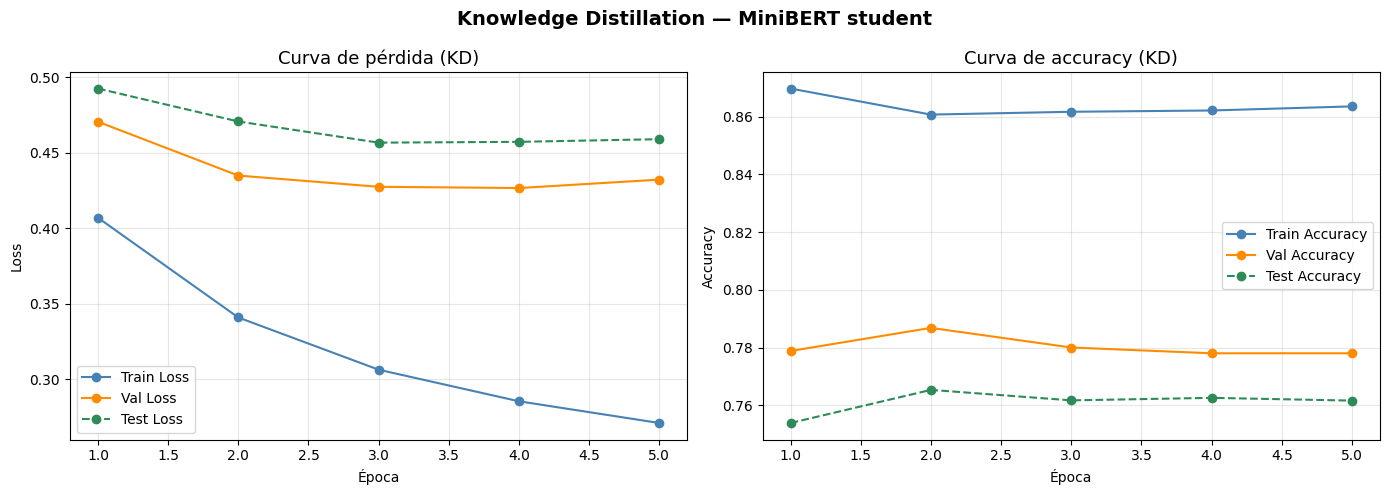

In [ ]:
epochs_range = range(1, len(train_losses_kd) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de pérdida por época para train, validación y test
axes[0].plot(epochs_range, train_losses_kd, marker="o", label="Train Loss",  color="steelblue")
axes[0].plot(epochs_range, val_losses_kd,   marker="o", label="Val Loss",    color="darkorange")
axes[0].plot(epochs_range, test_losses_kd,  marker="o", label="Test Loss",   color="seagreen", linestyle="--")
axes[0].set_title("Curva de pérdida (KD)", fontsize=13)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva de accuracy por época para train, validación y test
axes[1].plot(epochs_range, train_accuracies_kd, marker="o", label="Train Accuracy", color="steelblue")
axes[1].plot(epochs_range, val_accuracies_kd,   marker="o", label="Val Accuracy",   color="darkorange")
axes[1].plot(epochs_range, test_accuracies_kd,  marker="o", label="Test Accuracy",  color="seagreen", linestyle="--")
axes[1].set_title("Curva de accuracy (KD)", fontsize=13)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("Knowledge Distillation — MiniBERT student", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_kd.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.4.4. Evaluación final sobre el conjunto de test

La evaluación final sobre el conjunto de test (25.000 muestras) arroja una *accuracy* del **76.16%**, lo que supone una mejora clara respecto al modelo entrenado sin destilación.

El comportamiento por clase es relativamente equilibrado, aunque no perfecto. La clase positiva obtiene mayor `recall`, mientras que la clase negativa mantiene una mayor precisión. Este patrón indica que el modelo tiende ligeramente a favorecer las predicciones positivas, aunque menos que en el modelo base.

La matriz de confusión confirma esta tendencia, con un reparto bastante simétrico de aciertos y errores, lo que sugiere que la destilación ayuda a suavizar el sesgo del modelo sin eliminarlo por completo.

=== Resultados sobre Test (Knowledge Distillation) ===

              precision    recall  f1-score   support

    Negativo       0.82      0.67      0.74     12500
    Positivo       0.72      0.85      0.78     12500

    accuracy                           0.76     25000
   macro avg       0.77      0.76      0.76     25000
weighted avg       0.77      0.76      0.76     25000



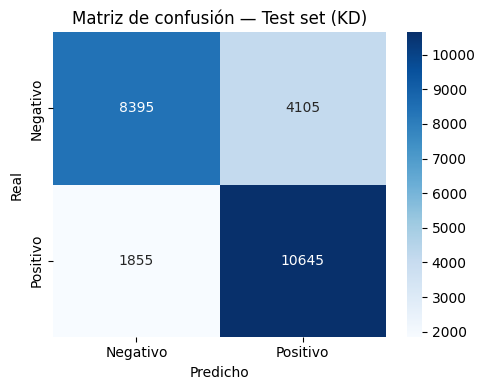

In [176]:
# Evaluación final sobre test (KD)

model_student.eval()

test_predictions_kd = []
test_labels_kd      = []

with torch.no_grad():
    for batch in test_dataloader_custom:
        batch       = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs     = model_student(**batch)
        predictions = torch.argmax(outputs.logits, dim=-1)
        test_predictions_kd.extend(predictions.cpu().numpy())
        test_labels_kd.extend(batch["labels"].cpu().numpy())

print("=== Resultados sobre Test (Knowledge Distillation) ===\n")
print(classification_report(
    test_labels_kd,
    test_predictions_kd,
    target_names=["Negativo", "Positivo"]
))

cm = confusion_matrix(test_labels_kd, test_predictions_kd)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negativo", "Positivo"],
            yticklabels=["Negativo", "Positivo"])
plt.title("Matriz de confusión — Test set (KD)")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_kd.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.4.5. Tiempo de inferencia sobre el test completo

El tiempo de inferencia total sobre el conjunto de test es de **4.76 segundos**, lo que equivale a **0.19 ms por muestra**.

Este resultado es prácticamente idéntico al del modelo sin destilación, ya que la arquitectura del *student* no cambia. La destilación únicamente afecta al proceso de entrenamiento, por lo que no introduce ningún coste adicional en despliegue.

In [177]:
# Inferencia KD
start_time = time.time()

with torch.no_grad():
    for batch in test_dataloader_custom:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        _     = model_student(**batch)

inference_time_kd = time.time() - start_time

print(f"Tiempo de inferencia: {inference_time_kd:.2f} s")
print(f"Tiempo por muestra:   {inference_time_kd / 25000 * 1000:.3f} ms")

Tiempo de inferencia: 4.76 s
Tiempo por muestra:   0.190 ms


### 3.4.6. Tabla comparativa final

La comparación entre los modelos del estudio muestra claramente el efecto de cada estrategia de entrenamiento.

El modelo `minibert-kd` mejora al `minibert-custom` en aproximadamente 3 puntos de *accuracy*, sin aumentar el coste de inferencia ni la complejidad del modelo. Esto confirma la utilidad de la destilación como técnica para extraer más rendimiento de arquitecturas pequeñas.

Aunque sigue por debajo de modelos preentrenados más grandes, como `bert-mini-uncased` o `distilbert-base-uncased`, su relación entre rendimiento, tamaño y velocidad lo convierte en la opción más equilibrada dentro del conjunto evaluado.

In [178]:
# Tabla comparativa final
acc_kd = accuracy_score(test_labels_kd, test_predictions_kd)
num_params_model_student     = sum(p.numel() for p in model_student.parameters())


tabla = [
    ["bert-mini-uncased", f"{num_params_bert_mini:,}", f"{test_acc_final_bert_mini:.4f}", f"{inference_time_bert_mini:.2f} s"],
    ["distilbert-base-uncased", f"{num_params_bert_mini_distilbert:,}", f"{test_acc_final_distilbert:.4f}", f"{inference_time_distilbert:.2f} s"],
    ["minibert-custom",         f"{params_custom:,}",      f"{acc_custom:.4f}",  f"{inference_time_custom:.2f} s"],
    ["minibert-kd",             f"{num_params_model_student:,}",  f"{acc_kd:.4f}", f"{inference_time_kd:.2f} s"],
]

headers = ["Modelo", "Parámetros", "Accuracy (Test)", "Tiempo Inferencia"]
print(tabulate(tabla, headers=headers, tablefmt="pretty"))

+-------------------------+------------+-----------------+-------------------+
|         Modelo          | Parámetros | Accuracy (Test) | Tiempo Inferencia |
+-------------------------+------------+-----------------+-------------------+
|    bert-mini-uncased    | 11,171,074 |     0.8807      |      21.73 s      |
| distilbert-base-uncased | 66,955,010 |     0.9101      |     215.39 s      |
|     minibert-custom     | 5,302,754  |     0.7282      |      4.29 s       |
|       minibert-kd       | 5,302,754  |     0.7616      |      4.76 s       |
+-------------------------+------------+-----------------+-------------------+


### 3.4.7. Reflexión final

El conjunto de experimentos permite observar con claridad el compromiso entre capacidad del modelo, coste computacional y estrategia de entrenamiento. Por un lado, el entrenamiento desde cero del modelo compacto muestra limitaciones evidentes de generalización, con tendencia al sobreajuste y rendimiento inferior. En contraste, la destilación de conocimiento permite mejorar significativamente este modelo sin modificar su arquitectura ni su coste de inferencia. Por otro lado, el principal aporte del *teacher* no es solo mejorar la precisión, sino proporcionar una señal de aprendizaje más rica y suave, que reduce el ruido en las actualizaciones y mejora la estabilidad del entrenamiento. Sin embargo, el método sigue siendo sensible a la configuración de hiperparámetros. En particular, el equilibrio entre la pérdida supervisada y la destilada resulta crítico: valores altos de ($\alpha$) pueden hacer que el modelo ignore las etiquetas reales, mientras que valores bajos reducen el efecto de la destilación. En este caso, la configuración con (T = 4.0) y ($\alpha$ = 0.7) ofrece el mejor compromiso entre estabilidad, aprendizaje y generalización. En conjunto, la destilación se consolida como la estrategia más eficiente del estudio para modelos compactos, al mejorar el rendimiento sin comprometer la eficiencia en inferencia.

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> Se ha ido resolviendo durante los apartados del ejercicio</p>
</div>

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">

# **Referencias**

Fuentes bibliográficas, recursos de aprendizaje, documentación técnica y herramientas de inteligencia artificial utilizadas en la elaboración de esta PEC.

<ul>

### **Recursos de aprendizaje**

<li>

<strong>De la Torre Gallart, J. (2024).</strong> <em>Transformadores. [Recurso de aprendizaje textual]. 1.ª ed. Barcelona: Fundació Universitat Oberta de Catalunya (FUOC).</em>

<strong>Utilizado en:</strong> Ejercicios 1, 2, 3, 4, 5, 6 y 7

* Proporciona los <strong>fundamentos teóricos de la arquitectura Transformer</strong>, incluyendo el mecanismo de self-attention, la codificación posicional y la técnica de <em>Knowledge Distillation</em>.
* Utilizado como referencia principal para comprender el <strong>diseño de modelos encoder-only tipo BERT</strong>, las estrategias de fine-tuning downstream y los principios que guían la construcción de modelos personalizados como <code>MiniBertForSequenceClassification</code>.

</li>

### **Fuentes Bibliográficas y Documentación Técnica**

<li>

<strong>Merity, S.; Xiong, C.; Bradbury, J.; Socher, R. (2016).</strong> <em>«Pointer Sentinel Mixture Models». arXiv preprint arXiv:1609.07843.</em><br>
Dataset disponible en HuggingFace: <a href="https://huggingface.co/datasets/Salesforce/wikitext">https://huggingface.co/datasets/Salesforce/wikitext</a>

<strong>Utilizado en:</strong> Ejercicios 1 y 2

* Utilizado para <strong>descargar el dataset <code>wikitext-2-raw-v1</code></strong> empleado en los ejercicios de generación de texto.
* Proporciona un corpus de texto extraído de Wikipedia, dividido en subconjuntos de <em>train</em>, <em>validation</em> y <em>test</em>, que se empleó para entrenar y comparar los modelos LSTM y Transformer desde cero.

</li>

<li>

<strong>Vaswani, A. et al. (2017).</strong> <em>«Attention Is All You Need». Advances in Neural Information Processing Systems, 30.</em>

<strong>Utilizado en:</strong> Ejercicios 2 y 3

* Referencia arquitectónica para el <strong>diseño del <code>TransformerLanguageModel</code></strong> implementado en el ejercicio 2, en particular para el uso de codificación posicional y capas de *multi-head self-attention*.
* Utilizado en el ejercicio 3 como base conceptual para la <strong>interpretación de los mapas de atención</strong> (*matriz de self-attention* y *token alignment*) y la evolución de los pesos entre la época 1 y la época final.

</li>

<li>

<strong>Devlin, J.; Chang, M.-W.; Lee, K.; Toutanova, K. (2018).</strong> <em>«BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding». arXiv preprint arXiv:1810.04805.</em>

<strong>Utilizado en:</strong> Ejercicios 4, 5, 6 y 7

* Proporciona la <strong>arquitectura de referencia BERT</strong> (bloques transformer con *self-attention* multi-cabeza, FFN, conexiones residuales y layer normalization) que se replica a escala reducida en el modelo personalizado <code>MiniBertForSequenceClassification</code> del ejercicio 6.
* Utilizado para justificar el uso del <strong>token [CLS] con un pooler lineal y activación tanh</strong> como cabeza de clasificación, siguiendo el diseño original de BERT, en los ejercicios 4, 6 y 7.

</li>

<li>

<strong>Maas, A. L. et al. (2011).</strong> <em>«Learning Word Vectors for Sentiment Analysis». Proceedings of the 49th Annual Meeting of the ACL, pp. 142–150.</em><br>
Dataset disponible en HuggingFace: <a href="https://huggingface.co/datasets/stanfordnlp/imdb">https://huggingface.co/datasets/stanfordnlp/imdb</a>

<strong>Utilizado en:</strong> Ejercicios 4, 5, 6 y 7

* Utilizado para <strong>descargar el dataset IMDB</strong> de análisis de sentimiento binario (positivo/negativo) con 25.000 muestras de entrenamiento y 25.000 de test.
* Su tamaño permite justificar el <strong>*fine-tuning* completo sin congelar capas</strong> en el ejercicio 5 (DistilBERT) y proporciona el problema de clasificación sobre el que se comparan los cuatro modelos de los ejercicios 4 a 7.

</li>

<li>

<strong>HuggingFace. (2026).</strong> Documentación oficial: Transformers, Datasets y Hub.<br>
<a href="https://huggingface.co/docs/transformers">https://huggingface.co/docs/transformers</a>

<strong>Utilizado en:</strong> Ejercicios 4, 5 y 7

* Utilizado como referencia técnica para el uso de <strong><code>AutoTokenizer</code>, <code>AutoModelForSequenceClassification</code>, <code>Trainer</code> y <code>TrainingArguments</code></strong> en el fine-tuning de <code>bert-mini-uncased</code> y <code>distilbert-base-uncased</code>.
* Empleado para la carga de los modelos preentrenados <strong><code>gaunernst/bert-mini-uncased</code></strong> y <strong><code>distilbert-base-uncased</code></strong> desde el Hub, así como para la gestión del <code>DataCollatorWithPadding</code> y el scheduler de learning rate.

</li>

<li>

<strong>PyTorch Team. (2026).</strong> Documentación oficial de PyTorch.<br>
<a href="https://pytorch.org">https://pytorch.org</a>

<strong>Utilizado en:</strong> Ejercicios 1, 2, 3, 6 y 7

* Utilizado como referencia para la implementación del <strong>bucle de entrenamiento manual</strong>, incluyendo <code>nn.LSTM</code>, <code>nn.MultiheadAttention</code>, <code>nn.TransformerEncoderLayer</code>, <code>Dataset</code>, <code>DataLoader</code> y optimizadores como <code>AdamW</code>.
* Empleado para confirmar el uso correcto del parámetro <strong><code>need_weights=True</code></strong> en <code>nn.MultiheadAttention</code>, necesario para extraer los pesos de atención en el ejercicio 3, y para implementar la <strong>función de pérdida combinada (KL Divergence + Cross-Entropy)</strong> en el ejercicio 7.

</li>

<li>

<strong>Hinton, G., Vinyals, O., & Dean, J. (2015).</strong>  Distilling the knowledge in a neural network. arXiv preprint arXiv:1503.02531.

<strong>Utilizado en:</strong> Ejercicios 7

* Utilizado como referencia teórica del Knownledge Distillation.

</li>

<li>

<strong>OpenAI. (2026).</strong> <em>ChatGPT (GPT-5.3).</em> /
<strong>Anthropic. (2026).</strong> <em>Claude (Haiku-4.5).</em>

<strong>Utilizado en:</strong> Ejercicios 1, 2, 3, 4, 5, 6 y 7

* Utilizado como <strong>herramienta de apoyo</strong> para revisar explicaciones conceptuales y resolver dudas técnicas puntuales durante el desarrollo de los ejercicios.

</li>

</ul>
</div>